# 6장 — 대규모 언어 모델로 지식 그래프 구축하기

| | |
| --- | --- |
| **책** | Alessandro Negro 외, *Knowledge Graphs and LLMs in Action* (Manning) **6장** |
| **해설 원본** | [06_..._ko_explained.md 열기](../../06_building_knowledge_graphs_with_large_language_models_ko_explained.md) |
| **원서 원문** | [06_....md 열기](../../06_building_knowledge_graphs_with_large_language_models.md) |
| **이 폴더** | [tasks.py](./tasks.py) · [listings/](./listings) · [importer/](./importer) · [Readme.md](./Readme.md) · [requirements.lock](./requirements.lock) |
| **원서 저장소** | [alenegro81/.../chapters/ch08 열기](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch08) |
| **리스팅 번호** | **오프셋으로 표현할 수 없다.** 리스팅 파일 이름이 업스트림 MEAP 번호(`8.x`)라 책 번호(`6.x`)와 **major 부터 다르고**, 파일이 `.py` 와 `.txt` 라 번호로 찾는 경로도 못 쓴다. 그래서 `study.toml` 이 번호 대신 `path` + `symbol` 로 선언한다 (아래 헬퍼 셀이 출력하는 대조표 참고) |
| **외부 서비스** | **Neo4j Enterprise + GDS + APOC.** OpenAI 키는 사실상 필요 없다 — 응답 캐시가 저장소에 동봉돼 있다 (다만 자리표시자 문자열은 있어야 한다. 「실행 환경」 참고) |

---

[5장](../../../chapter_05_extracting_domain_specific_knowledge_from_unstructured_data/src/ch05/05_chapter_guide.ipynb) 은 **프롬프트를 어떻게 다듬을 것인가** 를 물었다. 일기 한 페이지를 GPT 에 던지고, 돌아온 JSON 을 사람 눈으로 보면서 프롬프트를 v1 → v2 → v3 로 고쳤다. 6장은 그 프롬프트를 **150쪽짜리 일기 전체** 에 적용해 **진짜 지식 그래프를 만든다.** 그래서 이 장의 질문은 하나로 바뀐다 — **LLM 이 뱉은 지저분한 출력을 어떻게 쓸 만한 그래프로 만드나.**

| | **5장 (`ch05`)** | **6장 (이 노트북, `ch06`)** |
| --- | --- | --- |
| 다루는 단위 | 일기 **한 페이지** | 일기 **150쪽 전체** (기본 1회 실행은 100쪽) |
| 관심사 | 프롬프트를 어떻게 써야 쓸 만한 JSON 이 나오나 | 그 JSON 을 어떻게 **그래프** 로 만들어야 쓸 만한가 |
| 코드의 형태 | 프롬프트 문자열 세 벌 + API 호출 한 번 | [664줄짜리 적재·정규화·해소·KG 생성 파이프라인](./importer/ingest_and_process.py) |
| 산출물 | 화면에 찍히는 JSON | Neo4j 안의 **두 층짜리** 그래프 |
| 검증 방법 | 사람이 눈으로 본다 | 그래프 알고리즘으로 센다 (PageRank·매개 중심성·Louvain) |
| 이 장의 결론 | 프롬프트가 출력을 좌우한다 | **LLM 출력은 그래프의 재료일 뿐, 그래프는 그 뒤 세 단계가 만든다** |

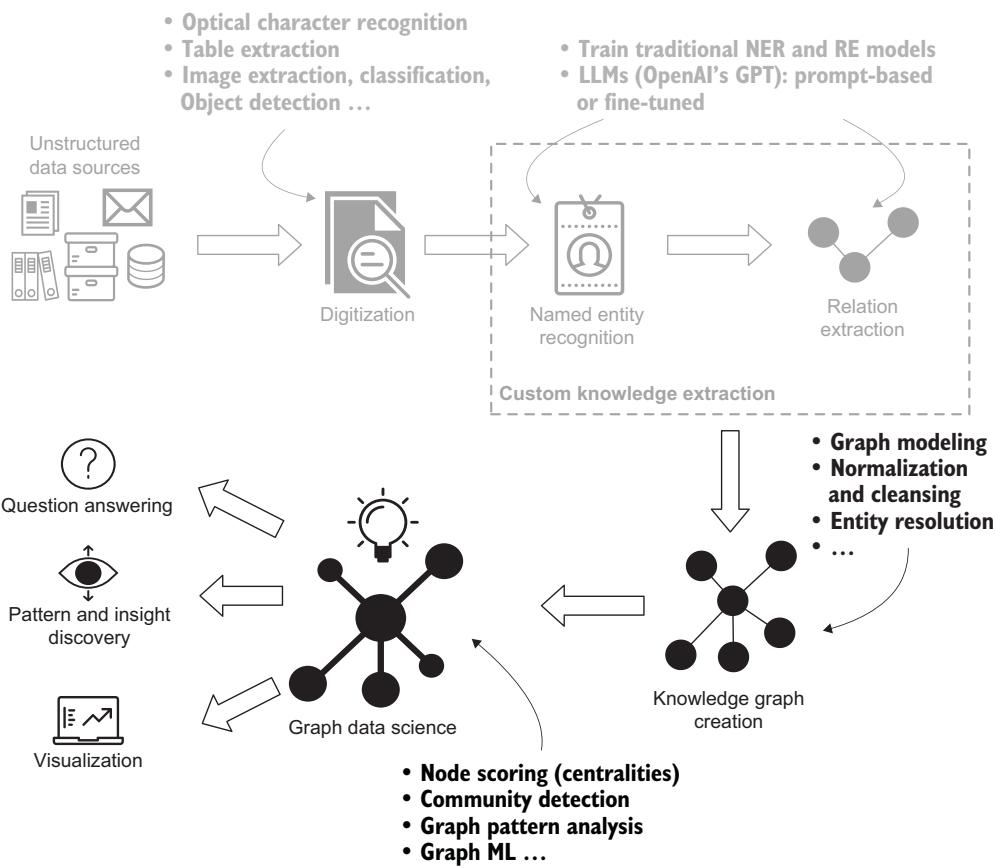

*그림 6.1 — 이 프로젝트의 멘탈 모델. 스캔 문서 → **OCR** → **NER · 관계 추출(RE)** → **개체 해소** → **지식 그래프** → **GraphML · 통찰** 로 이어지는 사슬이다. 5장이 왼쪽 절반(OCR 결과 텍스트에서 NER·RE 까지)을 다뤘고, 이 장은 **개체 해소부터 오른쪽 전부** 를 다룬다. 각 칸이 최신 ML 모델에 기대고 있다는 점이 이 그림의 요지다.*

### 이 장의 무게중심 — 세 단계

책 본문의 절 구성은 6.1\~6.4 지만, 실제로 코드가 하는 일은 **세 단계** 다. 이 노트북은 그 세 단계를 축으로 진행한다.

| 단계 | 무엇을 하나 | 책의 위치 | 이 노트북 |
| --- | --- | --- | --- |
| ① **정규화(normalization)** | 이름에 붙은 직함 접두사를 걷어내고, 직업명을 소문자로 통일한다 | 6.1.3 · **리스팅 6.1** | 6.1.3 절 셀 |
| ② **개체 해소(entity resolution)** | 같은 사람의 여러 표기를 하나로 모은다. 같은 페이지·앞 페이지 규칙 → `META_SIMILAR` 메타그래프 → **WCC** 로 점점 "그래프다워진다" | 6.1.4 · **그림 6.3** | 6.1.4 절 셀 |
| ③ **KG 층 생성 + 그래프 분석** | 스키마에 맞는 관계만 승격하고, PageRank·매개 중심성·Louvain 으로 영향력 네트워크를 읽는다 | 6.2 · **리스팅 6.2** · 그림 6.4\~6.6 | 6.2 절 셀 |

| 절 | 내용 | 이 절이 답하는 질문 | 리스팅 |
| --- | --- | --- | --- |
| 6.1 | 아카이브를 지식 그래프로 바꾸기 | 무엇이 아직 어려운가, LLM 은 그중 무엇을 지웠나 | — |
| 6.1.1 | 그래프 모델링 — 세 개의 층 | 왜 LLM 출력을 곧바로 KG 로 쓰지 않나 | — |
| 6.1.2 | 메타그래프 만들기 | 왜 `MERGE` 가 아니라 `CREATE` 인가 | — |
| 6.1.3 | 정규화와 정제 | 같은 사람이 두 노드로 갈라지는 것을 어떻게 막나 | **6.1** |
| 6.1.4 | 그래프 기반 개체 해소 | 문자열만으로 안 될 때 그래프가 무엇을 더 주나 | — |
| 6.2 | 지적 네트워크 분석 | 다 만든 그래프로 무엇을 하나 | **6.2** |
| 6.3 | RAC 프로젝트의 다음 단계 | 프로덕션에는 무엇이 더 필요한가 | — |
| 6.4 | LLM 시대에 KG 가 갖는 가치 | 왜 굳이 중간 단계를 두나 | — |
| — | 실습 6-A · 6-B · 6-C · 요약 | | |

> **한 문장 요약** — LLM 이 페이지마다 뱉은 엔티티·관계를 **병합하지 않고 그대로** 쌓아 메타그래프(`Entity` 층)를 만든 다음, 정규화 → 개체 해소 → 스키마 대조를 거쳐 **깨끗한 KG 층**(`Person`·`Organization`·`Occupation`)을 따로 만들고 둘을 `MAPPED_TO_*` 로 이어 두면, **출처를 잃지 않으면서도** 그래프 알고리즘을 돌릴 수 있는 영향력 네트워크가 남는다.

### 이 노트북이 특별히 신경 쓴 것

이 장은 **번호 붙은 리스팅이 둘뿐** 인데(6.1 · 6.2) 실제 내용의 9할은 [`importer/ingest_and_process.py`](./importer/ingest_and_process.py) 664줄에 들어 있다. 책 본문이 산문으로 설명하는 파이프라인 전 단계가 거기 있고, 리스팅 6.1 은 그 파일의 `normalize_entities()` 를 그대로 떼어 낸 것이다. 그래서 이 노트북은 리스팅 두 개를 보여주는 데 그치지 않고, **임포터의 각 단계를 원본 파일에서 꺼내 보이고 그 결과를 그래프에서 센다.**

또 하나. 이 장은 **진짜 API 키 없이, 네트워크 호출 0회로 완전히 재현된다** — 저장소에 LLM 응답 캐시가 동봉돼 있어서다 (다만 클라이언트 생성 때문에 자리표시자 문자열 하나는 필요하다). 그 대신 **책이 인쇄한 그림 속 이름들과 지금 캐시가 만드는 그래프가 서로 다르다.** 어디가 어떻게 다른지 아래에서 하나씩 대조한다. 이것은 책의 오류가 아니라, 저자들이 책을 쓸 때 쓴 KG 와 지금 동봉된 캐시가 만드는 KG 가 다르다는 뜻이다.

---
## 실행 환경 — Neo4j **Enterprise** 가 필요하고, OpenAI 키는 사실상 필요 없다

이 장의 실행 환경에는 헷갈리는 지점이 셋 있다. 먼저 정리한다.

### ① Neo4j 는 반드시 Enterprise 여야 한다

임포터가 **가장 먼저** 하는 일이 제약 생성인데 그 안에 `IS NODE KEY` 가 있다. 이것은 Enterprise 전용이다. Community 로는 첫 셀에서 막힌다.

```cypher
CREATE CONSTRAINT IF NOT EXISTS FOR (n:File) REQUIRE n.name IS NODE KEY;
CREATE CONSTRAINT IF NOT EXISTS FOR (n:Person) REQUIRE n.name_normalized IS NODE KEY;
```

플러그인도 둘 다 필요하다. 없으면 파이프라인 중간에서 죽는다.

| 플러그인 | 임포터가 쓰는 것 | 어느 단계에서 |
| --- | --- | --- |
| **APOC** | `apoc.convert.toJson` · `apoc.coll.toSet` | 메타그래프 적재 (`store_to_neo4j`) |
| | `apoc.text.join` | 정규화 (**리스팅 6.1**) |
| | `apoc.merge.node` · `apoc.merge.relationship` | KG 층 생성 (`create_kg`) |
| **GDS** | `gds.graph.project` · `gds.wcc.write` | 개체 해소 (`resolve_entities`) |
| | `gds.pageRank.write` · `gds.eigenvector.write` · `gds.betweenness.write` · `gds.louvain.write` | 그래프 분석 (`run_gds`) |

> **라이선스는 사용자가 직접 동의한다.** Neo4j Enterprise 는 평가 목적에 한해 무료이고, 컨테이너는 `NEO4J_ACCEPT_LICENSE_AGREEMENT=eval` 로 그 평가 계약에 동의해야 뜬다. 조건은 <https://neo4j.com/terms/enterprise_us/> 에 있으며 비상용·비프로덕션으로 제한된다. **이 저장소에서는 사용자가 이미 그 조건을 읽고 `eval` 로 동의해 컨테이너를 띄워 두었다.** 에이전트가 대신 수락하는 일은 없다.

```bash
docker ps --filter name=kglm-neo4j    # 어느 컨테이너가 떠 있는지 확인
```

> **`n10s` 와는 같이 못 쓴다.** 3장이 쓰는 `n10s` 는 Enterprise 와 Jackson 버전이 충돌해 죽는다(`NoSuchMethodError: JsonProperty.isRequired()`). 그래서 이 교재는 n10s 컨테이너와 Enterprise 컨테이너를 나눠 두고 필요할 때 전환한다. 이 장은 **Enterprise 쪽** 이다.

### ② LLM 응답 캐시가 동봉돼 있어 OpenAI 호출이 0회다

| 항목 | 값 |
| --- | --- |
| 원본 데이터 | [`data/ch8_rac_ww_1939.json`](../../../data/ch8_rac_ww_1939.json) — 워런 위버 일기 **150쪽**, 365 KB |
| LLM 응답 캐시 | `data/cache_llm/` — **156개 파일** |
| 캐시 키 | 페이지 id (`Warren Weaver_Diary_1939-1940_<page_idx>`), 재시도는 `..._retry` |
| 적중률 | 임포터가 기본 1회 실행에서 처리하는 100쪽이 **100% 적중** → **OpenAI 호출 0회** |

이것이 이 장의 큰 장점이다. 5장은 프록시든 진짜 키든 LLM 이 있어야 돌지만, **6장은 네트워크 없이도 그래프 전체를 만들 수 있다.** 아래 셀들의 수치가 전부 결정적인 것도 이 덕분이다.

> ⚠️ **다만 자리표시자 문자열이라도 `OPENAI_KEY` 는 있어야 한다.** 임포터는 캐시를 찾기 **전에** `OpenAI(base_url=..., api_key=self.openai_key)` 로 클라이언트를 먼저 만든다. `openai 1.69.0` 에서 `api_key` 가 `None` 이고 `OPENAI_API_KEY` 환경변수도 없으면 그 자리에서 `OpenAIError: The api_key client option must be set …` 이 난다 — **한 번도 호출하지 않는데도** 그렇다. 아래 파이프라인 셀은 그래서 `OPENAI_KEY` 에 더미 문자열을 넣어 준다. 업스트림 파일은 고치지 않는다.

> ⚠️ **캐시는 프롬프트·모델을 바꿔도 무효화되지 않는다.** [`Readme.md`](./Readme.md) 가 직접 경고한다. 키가 페이지 id 하나뿐이라, 프롬프트를 고쳐도 예전 응답이 그대로 재사용된다. 프롬프트를 바꿔 실험하려면 `data/cache_llm/` 을 비우거나 다른 곳으로 옮겨야 하고, 그 순간부터 **진짜 API 키와 비용** 이 필요해진다.

### ③ 업스트림 lock 과 실제 검증 버전이 다르다

| 패키지 | 이 챕터 `requirements.lock` | **이 노트북을 실행해 확인한 버전** |
| --- | --- | --- |
| `neo4j` | `4.4.11` | **5.28.4** |
| `openai` | `1.12.0` | **1.69.0** |
| Python | (지정 없음) | **3.10.18** (`study.toml` 고정) |

**lock 은 출처 기록이고 재현 기준은 이 노트북이 따로 보증한다.** 여기서 `neo4j` 를 4.4 로 내리면 이미 완성돼 출력까지 커밋된 다른 챕터들이 깨진다(3\~4장·9\~12장이 전부 드라이버 5.x 에서 실행됐다). 실측으로 **임포터 664줄 전체가 `neo4j 5.28.4` 에서 정상 완주** 했으므로 다운그레이드하지 않는다. `openai` 도 마찬가지다 — 이 장은 캐시 적중이라 SDK 를 쓰지도 않는다.

### 설치

교재 루트의 `.venv`(Python 3.10) 커널에서 돌아간다. 처음이면 교재 루트에서 [`setup_env.py`](../../../setup_env.py) 를 한 번 실행한다.

```bash
python3 setup_env.py
```

그다음 **이 챕터 폴더에서** 챕터별 의존성을 확인한다. 챕터마다 `requirements.lock` 이 다른 버전을 pin 하므로, 다른 챕터를 돌리다 왔다면 무엇이 바뀌는지 먼저 본다.

```bash
cd "source/Alessandro Negro - Knowledge Graphs and LLMs in Action/chapter_06_building_knowledge_graphs_with_large_language_models/src/ch06"
python tasks.py --list      # 타깃 목록 (업스트림 Makefile 은 init·import 둘)
python tasks.py import      # 임포터 실행 = make import 와 등가
```

> ⚠️ **`python tasks.py init` 은 신중하게.** 이 챕터의 lock 은 `neo4j==4.4.11` 과 `openai==1.12.0` 을 pin 하므로, 그대로 돌리면 공용 `.venv` 의 드라이버가 4.4 로 **내려간다.** 위 표대로 이 저장소는 5.28.4 를 재현 기준으로 삼으므로 `init` 은 돌리지 않는다. 필요한 패키지는 교재 공용 `base_packages` 에 이미 들어 있다.

### 실행 시간과 상태

| 셀 | 하는 일 | 비고 |
| --- | --- | --- |
| 환경 점검 | 패키지 · Neo4j 에디션 · 플러그인 · 데이터 · 현재 그래프 상태 | 1초 남짓 |
| **파이프라인** | 그래프가 **완전히 비어 있을 때만** 임포터를 돌린다 | LLM 호출 0회. 시간은 Cypher 쓰기와 GDS 가 전부 |
| 나머지 셀 전부 | **읽기 전용** 질의 | 각 1초 미만 |

> ⚠️ **임포터는 멱등이 아니다.** `build_kg()` 가 읽는 질의는 `MATCH (p:Page) WHERE NOT p:GPTProcessed … ORDER BY p.page_idx LIMIT 100` 이다. 즉 **아직 처리하지 않은 페이지 100쪽** 을 가져간다. 그래서 1회차는 `page_idx` 2\~101 의 100쪽을, **2회차는 남은 102\~151 의 50쪽을 추가로** 처리한다. 그 뒤 `create_kg()` 가 KG 층을 지우고 다시 만들므로 **이 노트북의 모든 수치가 달라진다.** 아래 파이프라인 셀이 "Page 노드가 하나도 없을 때만" 실행하도록 가드를 둔 이유가 이것이다. 2회차가 무엇을 더하는지는 실습 6-C 에서 **돌리지 않고** 캐시로 계산한다.

In [1]:
"""환경 점검 — 이 셀이 통과하면 이후 모든 셀을 돌릴 수 있다.

6장은 이 교재에서 외부 의존이 가장 무거운 축에 속한다. 그래서 넷으로 나눠 본다.

  1. 파이썬 패키지 — 임포터가 임포트하는 것 (neo4j · openai · tqdm)
  2. Neo4j 서버 — **에디션** 과 플러그인. 임포터가 제일 먼저 IS NODE KEY 제약을
     만들므로 Community 면 시작조차 못 한다. GDS·APOC 가 없으면 중간에 죽는다.
  3. 동봉 데이터와 LLM 응답 캐시 — 이 둘이 있으면 OpenAI 호출이 0회다.
  4. 지금 그래프가 어느 상태인가 — 비었나, 1차 배치(100쪽)까지인가, 150쪽 전부인가.

1~3 이 없으면 이후가 전부 막히므로 즉시 실패시킨다. 4 는 상태 보고일 뿐이다.
"""
import importlib
import platform
from pathlib import Path

from studykit import config, cypher

STUDY = config.load()     # 위로 올라가며 study.toml 을 찾는다
HERE = Path.cwd()         # 주피터는 노트북 폴더를 cwd 로 둔다
REPO_DIR = "ch06"         # 소스 폴더 = 책 장 번호 (업스트림 MEAP 에서는 ch08)
UPSTREAM_DIR = STUDY.upstream_dirs[REPO_DIR]   # "ch08" — study.toml 이 정본이다
DB = "neo4j"              # 이 장은 기본 DB 를 쓴다 (임포터가 _database = "neo4j")

assert (HERE / "listings").is_dir(), f"cwd 가 챕터 폴더가 아니다: {HERE}"
assert (HERE / "importer").is_dir(), f"importer/ 가 없다: {HERE}"

print("교재      :", STUDY.title)
print("파이썬    :", platform.python_version(), "(study.toml 고정:", STUDY.python + ")")
print("작업 폴더 :", HERE.name, " (책 6장 ↔ 업스트림", UPSTREAM_DIR + ")")

MEASURED = {}             # 아래 셀들이 실측값을 모으고, 요약 셀이 그대로 인용한다

# ---- 1. 파이썬 패키지 ---------------------------------------------------------
# lock 은 neo4j==4.4.11 · openai==1.12.0 을 pin 하지만 이 저장소의 재현 기준은
# 드라이버 5.x 다 (다른 챕터의 저장 출력이 그 위에서 만들어졌다). 그래서 lock 값과
# 실제 값을 나란히 찍어 차이를 눈에 보이게 둔다. 업스트림 lock 파일은 고치지 않는다.
REQUIRED = {
    "neo4j":  "임포터의 모든 Cypher. GraphDatabase.driver",
    "openai": "OpenAI 클라이언트 (캐시 적중이라 실제 호출은 0회)",
    "tqdm":   "util.base_importer 의 배치 진행 표시",
}
LOCKED = dict(
    line.split("==") for line in (HERE / "requirements.lock").read_text().split()
    if "==" in line
)

missing = []
print()
print(f"  {'패키지':<10}{'설치됨':<12}{'lock':<12}쓰는 곳")
for name, why in REQUIRED.items():
    try:
        module = importlib.import_module(name)
    except ImportError:
        missing.append(name)
        print(f"  ✗ {name:<8}{'없음':<12}{LOCKED.get(name, '—'):<12}{why}")
    else:
        version = getattr(module, "__version__", "?")
        pin = LOCKED.get(name, "—")
        mark = " " if pin in ("—", version) else "≠"
        print(f"  ✓ {name:<8}{version:<12}{pin + mark:<12}{why}")

if missing:
    raise RuntimeError(
        "패키지가 없다: " + ", ".join(missing)
        + "\n  교재 루트에서 python3 setup_env.py 를 돌려라."
        + "\n  (이 챕터의 python tasks.py init 은 neo4j 를 4.4 로 내리므로 쓰지 않는다)"
    )

# ---- 2. Neo4j 서버 : 에디션 · 플러그인 ----------------------------------------
# 이 장은 Neo4j 가 없으면 아무것도 못 하므로 플래그가 아니라 예외로 막는다.
NEEDED_PROCEDURES = {
    "apoc.merge.node":          "KG 층 노드 생성 (create_kg)",
    "apoc.merge.relationship":  "KG 층 관계 생성 · MAPPED_TO_* 연결",
    "gds.graph.project":        "해소·분석용 그래프 투영",
    "gds.wcc.write":            "개체 해소의 약결합 요소",
    "gds.pageRank.write":       "영향력 네트워크 PageRank",
    "gds.betweenness.write":    "매개 중심성 (그림 6.4)",
    "gds.louvain.write":        "커뮤니티 탐지",
}

with cypher.driver() as drv:
    with drv.session(database="system") as s:
        info = s.run("CALL dbms.components() YIELD versions, edition "
                     "RETURN versions[0] AS version, edition").single()
        databases = sorted({r["name"] for r in s.run("SHOW DATABASES YIELD name "
                                                     "RETURN DISTINCT name")})
    print(f"\nNeo4j     : {info['version']} ({info['edition']} edition)")
    print("데이터베이스:", databases)

    if info["edition"] != "enterprise":
        raise RuntimeError(
            "이 장은 Enterprise 가 필요하다. 임포터의 create_indices() 가 "
            "CREATE CONSTRAINT ... IS NODE KEY 를 쓰는데 Community 에는 없다.\n"
            "  4장에서 쓴 kglm-neo4j-ee 컨테이너를 띄워라 (라이선스는 사용자가 동의한다)."
        )

    with drv.session(database=DB) as s:
        have = {r["name"] for r in s.run("SHOW PROCEDURES YIELD name RETURN name")}
        versions = {}
        for label, expression in (("APOC", "apoc.version()"), ("GDS", "gds.version()")):
            try:
                versions[label] = s.run(f"RETURN {expression} AS v").single()["v"]
            except Exception as exc:                       # 플러그인 없음
                versions[label] = f"없음 ({type(exc).__name__})"

    print(f"  APOC     : {versions['APOC']}")
    print(f"  GDS      : {versions['GDS']}")
    absent = [p for p in NEEDED_PROCEDURES if p not in have]
    print()
    for name, why in NEEDED_PROCEDURES.items():
        print(f"  {'✓' if name in have else '✗'} {name:<26}{why}")
    if absent:
        raise RuntimeError(
            "필요한 프로시저가 없다: " + ", ".join(absent)
            + "\n  Neo4j 컨테이너에 apoc 과 graph-data-science 플러그인을 함께 올려야 한다."
        )

# ---- 3. 동봉 데이터와 LLM 응답 캐시 -------------------------------------------
# 임포터는 cwd 기준 ../../../data/ 를 본다. 노트북 cwd 가 이 챕터 폴더이므로 같은 곳이다.
DATA = STUDY.data
DIARY = DATA / "ch8_rac_ww_1939.json"
CACHE = DATA / "cache_llm"
PROMPT_FILES = ["gpt_prompt_task.txt", "gpt_prompt_example.txt", "gpt_prompt_example_output.txt"]

assert DIARY.is_file(), f"일기 데이터가 없다: {DIARY}"
assert CACHE.is_dir(), f"LLM 응답 캐시 폴더가 없다: {CACHE}"
for name in PROMPT_FILES:
    assert (DATA / name).is_file(), f"프롬프트 조각이 없다: {DATA / name}"

import json

DIARY_PAGES = sorted(json.loads(DIARY.read_text(encoding="utf-8")),
                     key=lambda p: p["page_idx"])
CACHE_KEYS = {p.stem for p in CACHE.glob("*.json")}
BATCH_LIMIT = 100                       # 임포터의 process_diaries_gpt(n_docs=100)
BATCH1 = DIARY_PAGES[:BATCH_LIMIT]
BATCH2 = DIARY_PAGES[BATCH_LIMIT:]

print(f"\n일기 데이터 : {DIARY.name}  {DIARY.stat().st_size / 1024:.0f} KB"
      f" · {len(DIARY_PAGES)}쪽 (page_idx {DIARY_PAGES[0]['page_idx']}"
      f"~{DIARY_PAGES[-1]['page_idx']})")
print(f"응답 캐시   : {len(CACHE_KEYS)}개 파일"
      f"  (재시도 응답 {sum(1 for k in CACHE_KEYS if k.endswith('_retry'))}개 포함)")
print(f"  1차 배치 {len(BATCH1)}쪽 (page_idx {BATCH1[0]['page_idx']}~{BATCH1[-1]['page_idx']}) "
      f"캐시 적중 {sum(1 for p in BATCH1 if p['id'] in CACHE_KEYS)}/{len(BATCH1)}")
print(f"  2차 배치 {len(BATCH2)}쪽 (page_idx {BATCH2[0]['page_idx']}~{BATCH2[-1]['page_idx']}) "
      f"캐시 적중 {sum(1 for p in BATCH2 if p['id'] in CACHE_KEYS)}/{len(BATCH2)}")
print("  -> 적중률 100% 이므로 OpenAI 호출은 0회다. 키가 없어도 그래프를 만들 수 있다.")

# ---- 4. 지금 그래프는 어느 상태인가 -------------------------------------------
STATE_QUERIES = {
    "Page":         "MATCH (n:Page) RETURN count(n) AS n",
    "GPTProcessed": "MATCH (n:GPTProcessed) RETURN count(n) AS n",
    "Entity":       "MATCH (n:Entity) RETURN count(n) AS n",
    "Person":       "MATCH (n:Person) RETURN count(n) AS n",
}


def graph_state() -> dict:
    """그래프의 현재 상태. 파이프라인 셀이 실행 여부를 판단하는 근거다."""
    with cypher.driver() as drv, drv.session(database=DB) as s:
        return {label: s.run(q).single()["n"] for label, q in STATE_QUERIES.items()}


STATE = graph_state()
print("\n현재 그래프 :", ", ".join(f"{k} {v}" for k, v in STATE.items()))
if STATE["Page"] == 0:
    print("  -> 비어 있다. 아래 파이프라인 셀이 임포터를 돌린다.")
elif STATE["GPTProcessed"] < STATE["Page"]:
    print(f"  -> 1차 배치까지 끝났다 ({STATE['GPTProcessed']}/{STATE['Page']}쪽 처리). "
          "이 노트북의 기준 상태다.")
else:
    print("  -> 150쪽 전부 처리된 상태다. 아래 수치가 이 노트북의 서술과 다를 수 있다 "
          "(임포터를 두 번 이상 돌린 그래프다).")

print("\n준비 완료.")

교재      : Knowledge Graphs and LLMs in Action
파이썬    : 3.10.18 (study.toml 고정: 3.10)
작업 폴더 : ch06  (책 6장 ↔ 업스트림 ch08)

  패키지       설치됨         lock        쓰는 곳
  ✓ neo4j   5.28.4      4.4.11≠     임포터의 모든 Cypher. GraphDatabase.driver


  ✓ openai  1.69.0      1.12.0≠     OpenAI 클라이언트 (캐시 적중이라 실제 호출은 0회)
  ✓ tqdm    4.69.1      —           util.base_importer 의 배치 진행 표시

Neo4j     : 5.26.28 (enterprise edition)
데이터베이스: ['ckg', 'hetionet', 'neo4j', 'ppi', 'system']
  APOC     : 5.26.28
  GDS      : 2.13.11

  ✓ apoc.merge.node           KG 층 노드 생성 (create_kg)
  ✓ apoc.merge.relationship   KG 층 관계 생성 · MAPPED_TO_* 연결
  ✓ gds.graph.project         해소·분석용 그래프 투영
  ✓ gds.wcc.write             개체 해소의 약결합 요소
  ✓ gds.pageRank.write        영향력 네트워크 PageRank
  ✓ gds.betweenness.write     매개 중심성 (그림 6.4)
  ✓ gds.louvain.write         커뮤니티 탐지

일기 데이터 : ch8_rac_ww_1939.json  365 KB · 150쪽 (page_idx 2~151)
응답 캐시   : 156개 파일  (재시도 응답 6개 포함)
  1차 배치 100쪽 (page_idx 2~101) 캐시 적중 100/100
  2차 배치 50쪽 (page_idx 102~151) 캐시 적중 50/50
  -> 적중률 100% 이므로 OpenAI 호출은 0회다. 키가 없어도 그래프를 만들 수 있다.

현재 그래프 : Page 150, GPTProcessed 100, Entity 2197, Person 461
  -> 1차 배치까지 끝났다 (100/150쪽 처리). 이 노트북의 기준 상태다.

준비 완료.


In [2]:
"""리스팅 접근 헬퍼 — 이 챕터의 번호 사정과, 번호 없는 '본체'.

책 리스팅 하나가 저장소의 어느 파일·어느 심볼인지는 study.toml 의
`[mapping.listings.ch06]` 이 정본이고, 그 선언을 해석하는 일은 공용 리더
`studykit.listing_source` 가 한다. 이 셀은 대응표도 ast 헬퍼도 들고 있지 않다 —
전에는 같은 표와 같은 파싱 코드를 챕터마다 복사해 두어 정본이 이름만 정본이었다.

    listing_source.chunk_for(STUDY, "ch06", "6.1")   -> .text / .origin() / .path
    listing_source.cross_reference(STUDY, "ch06")     -> 대조표 한 줄씩 (.title 포함)
    listing_source.unnumbered_listings(STUDY, "ch06") -> 책 번호를 못 받은 파일

이 챕터에만 있는 사정은 셋이다.

  1. **번호를 오프셋으로 표현할 수 없다.** 리스팅 파일이 MEAP 번호 8.x 라 책 6.x 와
     major 부터 다르다(업스트림이 MEAP 번호를 쓴다). minor 는 일치한다: 8.1↔6.1, 8.2↔6.2.
  2. **파일 확장자 때문에 번호 검색 경로도 못 쓴다.** cypher.listings() 는 .py 를
     의도적으로 제외하고, .txt 는 잡히지만 파일명 번호가 8.2 라 "6.2" 로 찾을 수 없다.
     그래서 study.toml 이 path + symbol("__main__" = 파일 전체)로 선언한다.
  3. **이 장의 본체는 번호가 없다.** importer/ingest_and_process.py 664줄이 책 본문이
     산문으로 설명하는 파이프라인 전부다. 리스팅 6.1 은 그 파일의 normalize_entities()
     를 그대로 떼어 낸 것이고, 리스팅 6.2 는 다 만든 그래프에 던지는 질의 한 개다.

업스트림 원본 파일은 어떤 경우에도 수정하지 않는다. 실행에 필요한 값(모델명·API 키
자리표시자)은 런타임 환경변수로만 조정한다.
"""
import contextlib
import importlib.util
import io
import time

from studykit import listing_source

IMPORTER_REL = "importer/ingest_and_process.py"

# 선언 전부를 책 번호 순으로 한 번 읽어 둔다. 제목도 여기서 나오므로 노트북은
# 제목 표의 사본을 들지 않는다 (원서 md 의 `Listing N.M` 캡션에서 리더가 뽑는다).
XREF = listing_source.cross_reference(STUDY, REPO_DIR)
NO_TITLE = "— (study.toml 에 title 선언이 필요하다)"
TITLES = {row.number: row.title or NO_TITLE for row in XREF}


def chunk(book_no):
    """책 리스팅 번호 -> 소스 조각."""
    return listing_source.chunk_for(STUDY, REPO_DIR, str(book_no))


def source_of(book_no) -> str:
    """책 리스팅 원문 문자열."""
    return chunk(book_no).text


def show(book_no, head=None) -> None:
    """책 리스팅 원문을 출력한다."""
    piece = chunk(book_no)
    print(f"── 책 Listing {book_no}  {TITLES.get(str(book_no), NO_TITLE)}")
    print(f"   출처: {piece.origin()}")
    lines = piece.text.splitlines()
    for line in (lines[:head] if head else lines):
        print("   ", line)
    if head and len(lines) > head:
        print(f"    ... (전체 {len(lines)}줄, head={head} 로 잘랐다)")


def show_symbol(rel_path: str, symbol: str, label: str = "", head=None) -> None:
    """책 번호가 없는 저장소 조각(임포터의 단계 함수 등)을 보여준다.

    공용 리더에 즉석 선언을 넘긴다 — study.toml 에 적을 만큼 '책 리스팅'은 아니지만
    이 장의 본체이므로 노트북이 반드시 실어야 하는 코드다. 줄 번호는 저장하지 않고
    리더가 매번 ast 로 다시 찾으므로 업스트림이 갱신돼도 조용히 어긋나지 않는다.
    """
    spec = listing_source.parse({"source": "repo-file", "path": rel_path, "symbol": symbol})
    piece = listing_source.read(spec, HERE)
    print(f"── {piece.origin()}" + (f"   — {label}" if label else ""))
    lines = piece.text.splitlines()
    for line in (lines[:head] if head else lines):
        print("   ", line)
    if head and len(lines) > head:
        print(f"    ... (전체 {len(lines)}줄, head={head} 로 잘랐다)")


def query_block(rel_path: str, symbol: str, const_name: str) -> str:
    """함수 안의 삼중따옴표 Cypher 상수 하나를 꺼낸다.

    QUERY_TITLES 처럼 **지역 변수** 로 선언된 질의는 심볼이 아니라 함수 안에 있어서
    listing_source 로 직접 가리킬 수 없다. 줄 번호를 노트북에 박으면 업스트림이
    갱신될 때 조용히 어긋나므로, 심볼 소스를 받아 상수 이름으로 찾는다.
    """
    spec = listing_source.parse({"source": "repo-file", "path": rel_path, "symbol": symbol})
    text = listing_source.read(spec, HERE).text
    head = text.index(f'{const_name} = """') + len(f'{const_name} = """')
    return text[head:text.index('"""', head)]


def load_module(rel_path: str, name: str):
    """저장소 파일을 모듈로 임포트한다. `__main__` 블록은 실행되지 않는다.

    파일명에 공백과 점이 있어 평범한 import 로는 불러올 수 없으므로 spec 을 직접
    만든다. 파일을 복사하거나 이름을 바꾸지 않는 것이 요점이다. 임포터도 모듈
    최상위에는 임포트와 클래스 정의뿐이라 Neo4j 에 붙지 않는다 — 드라이버는
    GraphDBBase.__init__ 이 만드는데 그 생성자는 __main__ 블록에서만 호출된다.
    """
    path = HERE / rel_path
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


def load_listing(book_no):
    """책 리스팅 파일 자체를 모듈로 임포트해 그 안의 상수를 꺼낸다.

    리스팅 6.1 은 상수 세 개 + `if __name__` 블록이므로 임포트해도 질의가 실행되지
    않는다. 원문을 다시 타이핑하지 않고 쓰기 위한 통로다.
    """
    path = chunk(book_no).path
    return load_module(str(path.relative_to(HERE)), "listing_" + str(book_no).replace(".", "_"))


def run_listing(book_no, db: str = DB, limit: int = 5, **params):
    """Cypher 리스팅을 실행하고 결과 일부를 보여준다. 반환값은 원시 레코드다."""
    started = time.time()
    with cypher.driver() as drv, drv.session(database=db) as s:
        rows = list(s.run(source_of(book_no), **params))
    print(f"책 {book_no} [{db}]: {time.time() - started:.2f}초, {len(rows)}행")
    for row in rows[:limit]:
        print("   ", " · ".join(fmt(v) for v in row.values()))
    return rows


def fmt(value) -> str:
    """Neo4j 값을 한 줄로. Path 는 사람이 읽는 경로 문자열로 편다."""
    from neo4j.graph import Node, Path, Relationship

    if isinstance(value, Path):
        parts = [value.start_node.get("name", "?")]
        for rel, node in zip(value.relationships, value.nodes[1:]):
            parts.append(f" -[{rel.type}]- {node.get('name', '?')}")
        return "".join(parts)
    if isinstance(value, Node):
        return f"({':'.join(value.labels)} {value.get('name', '?')})"
    if isinstance(value, Relationship):
        return f"-[{value.type}]->"
    if isinstance(value, float):
        return f"{value:.6f}"
    return str(value)[:70]


def read_rows(query: str, db: str = DB, **params) -> list:
    """읽기 전용 질의 한 개. 이 노트북의 대부분이 이것만 쓴다."""
    with cypher.driver() as drv, drv.session(database=db) as s:
        return [r.data() for r in s.run(query, **params)]


def table(rows: list, limit: int = 12) -> None:
    """딕셔너리 목록을 간단한 표로 찍는다."""
    if not rows:
        print("   (0행)")
        return
    columns = list(rows[0])
    widths = {c: max(len(str(c)), *(len(str(r.get(c))[:44]) for r in rows[:limit]))
              for c in columns}
    print("   " + "  ".join(f"{c:<{widths[c]}}" for c in columns))
    for row in rows[:limit]:
        print("   " + "  ".join(f"{str(row.get(c))[:44]:<{widths[c]}}" for c in columns))
    if len(rows) > limit:
        print(f"   … 총 {len(rows)}행 중 {limit}행")


# ---- 책 리스팅 -> 저장소 위치 대조표 ------------------------------------------
print(f"study.toml 이 선언한 {REPO_DIR} 리스팅 {len(XREF)}건\n")
print(f"{'책':<6}{'책 제목':<56}저장소 위치")
for row in XREF:
    note = f"  ({row.note})" if row.note else ""
    print(f"{row.number:<6}{TITLES[row.number][:54]:<56}{row.where}{note}")

unnumbered = listing_source.unnumbered_listings(STUDY, REPO_DIR)
print(f"\nlistings/ 에 있으나 어떤 책 번호도 가리키지 않는 파일: "
      f"{len(unnumbered)}개 {unnumbered if unnumbered else ''}")

# ---- 이 장의 본체: 번호 없는 파이프라인 ---------------------------------------
# 리스팅 대응표가 아니다. 책 본문이 산문으로만 설명하는 임포터의 단계와, 그 단계를
# 구현한 심볼을 잇는 지도다. 아래 절들이 이 순서대로 하나씩 열어 본다.
PIPELINE = [
    ("① 적재",        "DiariesImporter.ingest_diaries", "일기 JSON -> File · Page 노드 (문서 층)"),
    ("② 제약",        "DiariesImporter.create_indices", "IS NODE KEY 제약 + 텍스트 인덱스 (Enterprise 전용)"),
    ("③ LLM 추출",    "FullKG.process_diaries_gpt",     "미처리 페이지 100쪽을 GPT 로. 캐시가 있으면 호출 0회"),
    ("④ 메타그래프",  "FullKG.store_to_neo4j",          "Entity 를 MERGE 가 아니라 CREATE. 직함은 여기서 샌다"),
    ("⑤ 정규화",      "FullKG.normalize_entities",      "책 리스팅 6.1 과 같은 두 질의"),
    ("⑥ 개체 해소",   "FullKG.resolve_entities",        "같은/앞 페이지 규칙 -> META_SIMILAR -> WCC"),
    ("⑦ KG 층",       "FullKG.create_kg",               "스키마에 맞는 관계만 승격 + MAPPED_TO_* 연결"),
    ("⑧ 그래프 분석", "FullKG.run_gds",                 "PageRank · 고유벡터 · 매개 중심성 · Louvain"),
]

print(f"\n이 장의 본체 — {IMPORTER_REL} 의 단계 (책 번호가 없다):")
for stage, symbol, why in PIPELINE:
    spec = listing_source.parse(
        {"source": "repo-file", "path": IMPORTER_REL, "symbol": symbol})
    piece = listing_source.read(spec, HERE)
    print(f"  {stage:<12}L{piece.start:>3}-L{piece.end:<4} {symbol:<32}{why}")

print("\n실행 방법:")
print("    python tasks.py import       # = make import. 임포터 전체를 한 번 돌린다")
print("  이 노트북은 그래프가 비어 있을 때만 같은 스크립트를 하위 프로세스로 돌린다.")

study.toml 이 선언한 ch06 리스팅 2건

책     책 제목                                                    저장소 위치
6.1   Normalizing people and occupations                      listings/8.1 Normalization of persons and occupations.py  L1-L27  (파일 전체)
6.2   Showing the influence network related to cyclotron res  listings/8.2 Show influence network related to the cyclotron research.txt  L1-L4  (파일 전체)

listings/ 에 있으나 어떤 책 번호도 가리키지 않는 파일: 0개 

이 장의 본체 — importer/ingest_and_process.py 의 단계 (책 번호가 없다):
  ① 적재        L 51-L63   DiariesImporter.ingest_diaries  일기 JSON -> File · Page 노드 (문서 층)
  ② 제약        L 18-L39   DiariesImporter.create_indices  IS NODE KEY 제약 + 텍스트 인덱스 (Enterprise 전용)
  ③ LLM 추출    L220-L260  FullKG.process_diaries_gpt      미처리 페이지 100쪽을 GPT 로. 캐시가 있으면 호출 0회
  ④ 메타그래프     L159-L218  FullKG.store_to_neo4j           Entity 를 MERGE 가 아니라 CREATE. 직함은 여기서 샌다
  ⑤ 정규화       L275-L295  FullKG.normalize_entities       책 리스팅 6.1 과 같은 두 질의
  ⑥ 개체 해소     L297-L400  FullKG.resolve_entities         같

---
## 6.1 아카이브를 지식 그래프로 바꾸기 — 아직 남은 난제들과 LLM 시대의 행운

5장에서 프롬프트를 다듬어 GPT 가 깔끔한 JSON 을 내놓게 만들었다. 그런데 그것만으로 지식 그래프가 되지는 않는다. 이 절은 **아직 남은 일곱 가지 난제** 를 먼저 늘어놓는다. 늘어놓는 이유가 있다 — 그중 **몇 개는 LLM 이 이미 지워 주었고, 몇 개는 그대로 남아** 이 장의 나머지가 그것을 처리하기 때문이다.

| 난제 | 무엇이 문제인가 | 지금은? |
| --- | --- | --- |
| **아날로그 타자기 문서** | 종이를 스캔해 OCR 로 텍스트를 만들어야 한다 (Tesseract, 클라우드 OCR) | 이 장의 범위 **밖**. `data/ch8_rac_ww_1939.json` 이 이미 OCR 결과다 |
| **역사적 문서** | 지금은 연구되지 않는 분야가 많아, 중의성 해소의 기준으로 삼을 **정답지(사전·지식 베이스)가 세상에 없다** | 그대로 남는다. 그래서 이 장의 해소는 외부 KB 대조가 아니라 **그래프 내부 신호** 로 한다 |
| **낯선 언어 관습** | 담당자마다 축약 습관이 다르다. `J. R. Smith` → `S.`, `University of California` → `U.Cal.` 기성 상호참조 모델은 전부 실패했다 | **LLM 이 상당 부분 지웠다.** 프롬프트가 "항상 완전한 이름만 출력하라" 고 지시하면 GPT 가 상호참조 해소를 **은연중에** 해 준다 |
| **도메인 특화 개체명** | 이 도메인의 핵심 개체는 **직업(Occupation)** 인데 — 연구 분야·기술·치료법·질병이 뒤섞이고 세분화 정도도 제각각이다. 쓸 만한 기성 NER 모델이 (질병 빼고) 없다 | **LLM 이 지웠다.** 프롬프트에 관심 개체 목록을 적어 주는 것으로 끝난다 |
| **높은 관계 복잡도** | 한 페이지에 유의미한 관계가 수십 개다. 관계 추출 스키마를 잘못 정하면 쓸모없는 지식만 잔뜩 건진다 | 그대로 남는다. 그래서 프롬프트가 **관심 관계 6종** 을 못박는다 |
| **정규화·정제·해소·중의성 해소** | 문서마다 표기가 다르고, 대화는 몇 달·몇 년에 걸친 연쇄의 일부다 | **이 장의 본론.** 6.1.3 · 6.1.4 절이 여기에 답한다 |
| **비정형 소스 간 연결** | 일기와 이사회 회의록을 하나의 KG 로 화해시키면 "어떤 대화가 어떤 보조금이 됐나" 를 물을 수 있다 | 책의 범위 **밖**. 6.3 절이 다음 단계로만 언급한다 |

정리하면 **LLM 이 지운 것은 "언어 이해" 쪽 난제** 이고, **남은 것은 "동일성 판정" 쪽 난제** 다. 이름을 읽어 내는 일은 GPT 가 하지만, *"26쪽의 `E. O. Lawrence` 와 99쪽의 `Lawrence` 가 같은 사람인가"* 는 여전히 우리가 판정해야 한다. 그 판정에 **그래프가 무기가 된다** 는 것이 이 장의 주장이다.

> 이 책이 계속 쓰는 비유로 옮기면 이렇다. **LLM 은 아는 것이 많지만 없는 사실을 그럴듯하게 지어내는 달변가** 이고, **지식 그래프는 검증된 사실만 적어 둔 대장(臺帳)** 이다. 6장은 달변가의 말을 받아 적어 대장으로 옮기는 절차를 다룬다.

---
### 6.1.1 그래프 모델링 — 세 개의 층, 그리고 이중 층 구조

이 장에서 가장 중요한 설계 결정이 여기 있다. **LLM 출력을 그대로 지식 그래프로 쓰지 않는다.** 원출력을 담는 층과 정제 결과를 담는 층을 **따로 두고** 둘을 관계로 잇는다.

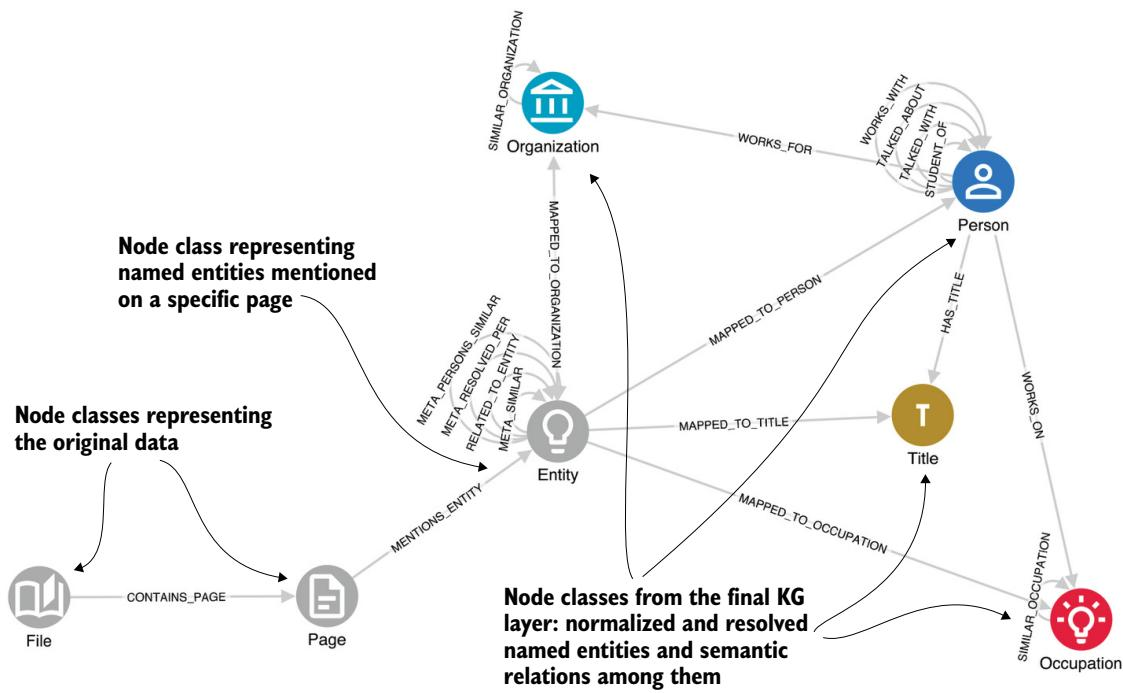

*그림 6.2 — RAC 프로젝트의 (단순화한) KG 스키마. 위에서부터 **문서 층**(`File`·`Page`), **메타그래프 층**(`Entity` 와 그들 사이의 `RELATED_TO_ENTITY`), **KG 층**(`Person`·`Title`·`Organization`·`Occupation` 과 `WORKS_ON`·`WORKS_FOR` 같은 관계)이다. 층 사이는 `CONTAINS_PAGE` · `MENTIONS_ENTITY` · `MAPPED_TO_*` 로 이어진다. 이 그림의 요점은 **`Entity` 와 `Person` 이 둘 다 남는다** 는 것이다 — 하나가 다른 하나를 대체하지 않는다.*

| 층 | 노드 | 관계 | 무엇인가 |
| --- | --- | --- | --- |
| **문서 층** (document-level) | `File` · `Page` | `CONTAINS_PAGE` | 최초 적재 결과. 파일명·저자, 페이지의 최종 정제 텍스트 |
| **메타그래프 층** (metagraph) | `Entity` | `MENTIONS_ENTITY` · `RELATED_TO_ENTITY` | **병합하지 않은** GPT 원출력. 어느 페이지에서 나왔는지가 함께 남는다 |
| **KG 층** | `Person` · `Title` · `Organization` · `Occupation` | `WORKS_ON` · `WORKS_FOR` · `TALKED_WITH` · `TALKED_ABOUT` · `STUDENT_OF` · `WORKS_WITH` | 정규화·정제·해소가 끝난 최종 개체와 관계 |

두 층을 잇는 것이 **`MAPPED_TO_PERSON` · `MAPPED_TO_ORGANIZATION` · `MAPPED_TO_OCCUPATION`** 이다. 임포터가 KG 노드를 만들 때마다 원래 `Entity` 에서 새 KG 노드로 화살표를 하나 걸어 둔다.

```cypher
CALL apoc.merge.node([label1], {name_normalized: toLower(coalesce(e1.name_normalized, e1.name))},
                     {name: coalesce(e1.name_normalized, e1.name), count: 0}) YIELD node AS n1
SET n1.count = n1.count + 1
CALL apoc.merge.relationship(e1, "MAPPED_TO_" + toUpper(label1), {}, {}, n1) YIELD rel
```

이 이중 층 구조가 무엇을 사 주는가. 넷이다.

| 이득 | 왜 그런가 |
| --- | --- |
| **설명 가능성** | KG 의 어떤 관계든 `MAPPED_TO_*` 를 거꾸로 타면 `Entity` → `Page` → 원문 텍스트에 닿는다. "이 주장의 근거가 몇 쪽인가" 에 답할 수 있다 |
| **재생성 가능성** | 해소 규칙을 고쳐도 LLM 을 다시 부를 필요가 없다. **메타그래프에서 KG 층만 다시 만들면 된다** — 실제로 `create_kg()` 는 매번 KG 층을 통째로 지우고 새로 만든다 |
| **추적 가능성** | 유지·보수하는 데이터 과학자가 노드와 관계의 출처를 바로 볼 수 있다 |
| **집계 가능성** | 여러 페이지에 흩어진 언급을 합치면서도(`count` 속성이 언급 횟수를 센다) 원본 정보를 잃지 않는다 |

> **KG 노드의 키는 `name_normalized` 다.** `apoc.merge.node` 가 `{name_normalized: toLower(...)}` 로 매칭하므로, 정규화·해소 단계가 이 속성을 어떻게 바꿔 놓았느냐가 **KG 노드가 몇 개가 될지를 그대로 결정한다.** 6.1.3·6.1.4 절이 하는 일이 전부 이 한 속성을 다듬는 일이다.

In [3]:
"""파이프라인 실행 — 그래프가 **완전히 비어 있을 때만** 돈다.

왜 가드가 이렇게 보수적인가. 임포터가 멱등이 아니기 때문이다. build_kg() 의 읽기
질의는 다음과 같다.

    MATCH (p:Page) WHERE NOT p:GPTProcessed RETURN ... ORDER BY p.page_idx LIMIT $limit

즉 "아직 처리하지 않은 페이지 100쪽"을 가져간다. 그래서 두 번째 실행은 남은 50쪽
(page_idx 102~151)을 **추가로** 처리하고, 이어지는 create_kg() 가 KG 층을 지우고 다시
만든다. 결과적으로 이 노트북의 모든 수치가 바뀐다. "Page 노드가 하나도 없을 때만"
이라는 조건은 그 사고를 막기 위한 것이다. 두 번째 실행이 무엇을 더하는지는 실습 6-C
에서 **돌리지 않고** 캐시로 계산한다.

실행은 업스트림 스크립트를 그대로 하위 프로세스로 부른다 (= `python tasks.py import`
= `make import`). 두 가지만 런타임에 손본다. 파일은 고치지 않는다.

  · OPENAI_KEY 에 더미 문자열을 넣는다. 임포터는 캐시를 찾기 **전에** OpenAI 클라이언트를
    만드는데, openai 1.69.0 은 키가 없으면 그 자리에서 OpenAIError 를 던진다.
    한 번도 호출하지 않는데도 그렇다.
  · 출력을 캡처해 요약만 찍는다. 임포터는 페이지마다 GPT 원출력을 통째로 print 하므로
    100쪽이면 수만 줄이 된다.
"""
import os
import subprocess
import sys

MARKERS = ("Read ", "Reading pages", "=== Finished", "Rerunning", "Normalising",
           "Resolving", "Cleansing", "Creating", "Created ", "Running", "\tPageRank",
           "\teigenvector", "\tbetweenness", "\tLouvain")

state = graph_state()
if state["Page"] == 0:
    print("그래프가 비어 있다 -> 임포터를 돌린다 (LLM 호출 0회, 캐시 100% 적중).")
    env = os.environ.copy()
    # 자리표시자. 캐시가 전부 맞으므로 이 값이 쓰이는 일은 없다.
    env.setdefault("OPENAI_KEY", "cache-only-no-api-call")
    env.setdefault("OPENAI_BASE_URL", "https://api.openai.com/v1")
    env.setdefault("OPENAI_MODEL", "gpt-4o-mini")
    started = time.time()
    proc = subprocess.run([sys.executable, "importer/ingest_and_process.py"],
                          cwd=str(HERE), env=env, capture_output=True, text=True)
    elapsed = time.time() - started
    for line in (proc.stdout or "").splitlines():
        if line.startswith(MARKERS):
            print("   ", line)
    if proc.returncode != 0:
        print("\n--- stderr 끝부분 ---")
        for line in (proc.stderr or "").strip().splitlines()[-12:]:
            print("   ", line)
        raise RuntimeError(f"임포터가 실패했다 (exit={proc.returncode})")
    print(f"\n   임포터 완료: {elapsed:.0f}초 (exit=0)")
    MEASURED["임포터 실행 시간(이 실행)"] = f"{elapsed:.0f}초"
    state = graph_state()
else:
    print(f"그래프가 이미 있다 (Page {state['Page']} · GPTProcessed {state['GPTProcessed']})"
          " -> 임포터를 돌리지 않는다.")
    print("   다시 만들고 싶으면 먼저 그래프를 비워라:  MATCH (n) DETACH DELETE n")
    print("   (그 상태에서 이 셀을 다시 돌리면 1회차와 같은 결과가 나온다 — 캐시가 같으므로)")

# ---- 층별 실측 ----------------------------------------------------------------
LABEL_CENSUS = """
MATCH (n) UNWIND labels(n) AS label
RETURN label, count(*) AS n ORDER BY n DESC
"""
REL_CENSUS = """
MATCH ()-[r]->()
RETURN type(r) AS type, count(*) AS n ORDER BY n DESC
"""

labels = {r["label"]: r["n"] for r in read_rows(LABEL_CENSUS)}
rels = {r["type"]: r["n"] for r in read_rows(REL_CENSUS)}

LAYER_OF_LABEL = {
    "File": "① 문서", "Page": "① 문서", "GPTProcessed": "① 문서(라벨)",
    "Entity": "② 메타그래프",
    "Person": "③ KG", "Organization": "③ KG", "Occupation": "③ KG", "Title": "③ KG",
}
LAYER_OF_REL = {
    "CONTAINS_PAGE": "① 문서",
    "MENTIONS_ENTITY": "①↔②", "RELATED_TO_ENTITY": "② 메타그래프",
    "META_SIMILAR": "② 해소용", "META_PERSONS_SIMILAR": "② 해소용",
    "META_RESOLVED_PER": "② 해소용",
    "MAPPED_TO_PERSON": "②↔③", "MAPPED_TO_ORGANIZATION": "②↔③",
    "MAPPED_TO_OCCUPATION": "②↔③", "MAPPED_TO_TITLE": "②↔③",
    "WORKS_ON": "③ KG", "WORKS_FOR": "③ KG", "TALKED_WITH": "③ KG",
    "TALKED_ABOUT": "③ KG", "WORKS_WITH": "③ KG", "STUDENT_OF": "③ KG",
    "HAS_TITLE": "③ KG", "SIMILAR_OCCUPATION": "③ KG", "SIMILAR_ORGANIZATION": "③ KG",
}

print(f"\n{'층':<14}{'라벨':<16}개수")
for label, n in sorted(labels.items(), key=lambda kv: -kv[1]):
    print(f"{LAYER_OF_LABEL.get(label, '?'):<14}{label:<16}{n:>6}")
print(f"{'—':<14}{'Title':<16}{labels.get('Title', 0):>6}   <- 업스트림 버그. 아래에서 재현한다")

print(f"\n{'층':<14}{'관계':<24}개수")
for rel_type, n in sorted(rels.items(), key=lambda kv: -kv[1]):
    print(f"{LAYER_OF_REL.get(rel_type, '?'):<14}{rel_type:<24}{n:>6}")

KG_REL_TYPES = ["WORKS_ON", "WORKS_FOR", "TALKED_WITH", "TALKED_ABOUT",
                "WORKS_WITH", "STUDENT_OF", "HAS_TITLE"]
kg_total = sum(rels.get(t, 0) for t in KG_REL_TYPES)
print(f"\nKG 층 관계 합계: {kg_total}  <- 임포터가 찍는 'Created N KG relations' 와 같은 수다")

MEASURED["라벨별 노드 수"] = labels
MEASURED["관계 유형별 수"] = rels
MEASURED["KG 층 관계 합계"] = kg_total

그래프가 이미 있다 (Page 150 · GPTProcessed 100) -> 임포터를 돌리지 않는다.
   다시 만들고 싶으면 먼저 그래프를 비워라:  MATCH (n) DETACH DELETE n
   (그 상태에서 이 셀을 다시 돌리면 1회차와 같은 결과가 나온다 — 캐시가 같으므로)

층             라벨              개수
② 메타그래프       Entity            2197
③ KG          Person             461
③ KG          Occupation         328
③ KG          Organization       169
① 문서          Page               150
① 문서(라벨)      GPTProcessed       100
① 문서          File                 1
—             Title                0   <- 업스트림 버그. 아래에서 재현한다

층             관계                      개수
② 해소용         META_SIMILAR              2553
①↔②           MENTIONS_ENTITY           2197
② 메타그래프       RELATED_TO_ENTITY         2123
②↔③           MAPPED_TO_PERSON           691
③ KG          WORKS_ON                   467
②↔③           MAPPED_TO_OCCUPATION       369
③ KG          WORKS_FOR                  362
②↔③           MAPPED_TO_ORGANIZATION     257
② 해소용         META_PERSONS_SIMILAR       251
③ KG          TALKED_WITH           

---
### 6.1.2 메타그래프 만들기 — 병합하지 말고 일단 다 기록하라

몇 페이지가 넘는 텍스트를 LLM 에 넣으려면 먼저 **청킹 전략(chunking strategy)** 을 정해야 한다. 토큰 한도에 걸리거나, 너무 긴 텍스트에서 품질이 떨어지는 것을 피하기 위해서다. 이 장은 가장 단순한 방법을 쓴다 — **페이지 단위** 로 자른다.

> **참고** RAC 프로젝트에는 1만 쪽이 넘는 문서가 있었지만, 이 예제는 워런 위버(Warren Weaver) 일기 중 **150쪽** 만 골랐다. 타자기로 친 1939년 문서이므로 디지털화 과정에서 일부 이름의 철자가 틀렸을 수 있다. 아래에서 실제로 그런 사례를 만난다.

#### 프롬프트는 네 조각으로 조립된다

임포터는 `data/` 의 텍스트 파일 세 개를 읽어 대화 메시지 네 개를 만든다. 5장의 프롬프트 v3 가 여기에 그대로 들어와 있다.

| 메시지 역할 | 내용 | 파일 |
| --- | --- | --- |
| `system` | 과제 정의 — 관심 개체 5종, 관심 관계 6종, `talked about` 은 감정까지, "성만 나오는 경우가 많다", **"항상 완전한 이름만 출력하라"** | `gpt_prompt_task.txt` |
| `user` | 예시 입력 (가상의 일기 한 쪽) | `gpt_prompt_example.txt` |
| `assistant` | 그 입력에 대한 **모범 JSON 출력** | `gpt_prompt_example_output.txt` |
| `user` | 진짜 일기 페이지 텍스트 | `Page.text` |

`temperature=0.` 과 `max_tokens=2000` 으로 호출한다. 온도 0 이므로 같은 모델·같은 프롬프트면 출력이 대체로 재현되지만, 어차피 **응답 캐시가 있어서 이 노트북에서는 호출 자체가 일어나지 않는다.**

#### `MERGE` 가 아니라 `CREATE` 다 — 이 장의 핵심 결정

```cypher
UNWIND $entities AS ent
CREATE (e:Entity)          // MERGE 가 아니다!
SET e += ent, e.all_properties = apoc.convert.toJson(ent)
MERGE (n)-[r:MENTIONS_ENTITY]->(e)
```

같은 페이지에서 `E. O. Lawrence` 가 나오고 다른 페이지에서도 나오면 **`Entity` 노드가 두 개 생긴다.** 일부러 그렇게 한다. 이유는 이렇다.

| 만약 `MERGE` 였다면 | `CREATE` 라서 |
| --- | --- |
| 이름이 같으면 한 노드가 된다. 그런데 **이름이 같다고 같은 사람이 아니다** (일기에는 Irving Roberts · Irving Langmuir 가 따로 있다) | 언급 하나에 노드 하나. 동일성 판정을 **나중에, 근거를 모아서** 한다 |
| 이름이 다르면 절대 합쳐지지 않는다 (`Lawrence` ≠ `E. O. Lawrence`) | 표기가 달라도 관계 근거로 이을 수 있다 |
| 어느 페이지에서 왔는지 뭉개진다 | 각 언급이 자기 페이지를 `MENTIONS_ENTITY` 로 가리킨다 |

정리하면 **`CREATE` 는 "판단을 미루는" 결정** 이다. 그리고 판단을 미룰 수 있게 해 주는 것이 바로 6.1.1 절의 이중 층 구조다.

#### 관계도 페이지 안에서만 이어진다

```cypher
MATCH (n)-[:MENTIONS_ENTITY]->(e1:Entity {id: rel.source})
MATCH (n)-[:MENTIONS_ENTITY]->(e2:Entity {id: rel.target})
MERGE (e1)-[r:RELATED_TO_ENTITY {type: rel.type}]->(e2)
```

GPT 가 준 `id` 는 **그 페이지 안에서만 유효한 정수** 다. 그래서 양 끝을 반드시 같은 페이지(`n`)에서 찾는다. 여기에 조용한 손실이 하나 있다 — **GPT 가 그 페이지에 없는 `id` 를 가리키면 그 관계는 통째로 사라진다.** `MATCH` 가 실패하면 그 행이 조용히 빠질 뿐 오류가 나지 않는다. 아래 셀이 그 손실을 센다.

#### 실패한 응답은 한 번 더 부른다

`parse_gpt_output()` 이 JSON 파싱에 실패하면 그 페이지는 저장하지 않고 `failed_pages` 에 모아 두었다가, 전부 끝난 뒤 **캐시 키 뒤에 `_retry` 를 붙여** 다시 부른다. 저장소에 동봉된 캐시에는 그 재시도 응답까지 들어 있어서, 실패-재시도 흐름도 API 없이 그대로 재현된다.

In [4]:
"""메타그래프의 산술을 캐시만으로 재현한다 — Neo4j 없이, 완전히 결정적으로.

왜 이 셀이 있나. 그래프에 들어간 숫자(Entity 2197 · RELATED_TO_ENTITY 2123)가 어디서
왔는지 알아야 그 다음 단계들이 무엇을 줄였는지 말할 수 있기 때문이다. 그런데 그
숫자는 Neo4j 를 열지 않아도 **동봉 캐시만으로 정확히 나온다.** LLM 호출이 없으니
전부 결정적이다.

파싱은 **책의 코드를 그대로 쓴다.** parse_gpt_output() 을 노트북에서 다시 구현하면
'책이 하는 일'이 아니라 '내가 하는 일'을 세게 된다. 임포터를 모듈로 임포트해 그
staticmethod 를 부른다 (모듈 최상위에는 임포트와 클래스 정의뿐이라 DB 에 붙지 않는다).
실패 응답을 만나면 원문을 통째로 print 하므로 그 출력만 삼킨다.
"""
from collections import Counter

IMPORTER = load_module(IMPORTER_REL, "ch08_importer")
parse_gpt_output = IMPORTER.FullKG.parse_gpt_output


def cached(page, retry: bool = False):
    """캐시에서 한 페이지의 GPT 응답 원문을 읽는다 (임포터의 openai_query 와 같은 규칙)."""
    key = page["id"] + ("_retry" if retry else "")
    path = CACHE / f"{key}.json"
    return json.loads(path.read_text(encoding="utf-8")) if path.is_file() else None


def parsed(page):
    """임포터가 실제로 저장하는 결과. 1차 실패면 _retry 응답을 쓴다."""
    quiet = io.StringIO()
    with contextlib.redirect_stdout(quiet):
        first = parse_gpt_output(cached(page))
        if not first["failed"]:
            return first, False
        retry_raw = cached(page, retry=True)
        return (parse_gpt_output(retry_raw) if retry_raw is not None else first), True


entity_labels = Counter()
relation_types = Counter()
n_entities = n_titles = n_relations = 0
resolved_relations = 0          # 양 끝 id 가 그 페이지에 실재하는 관계
unique_relations = 0            # 위에서 MERGE 중복까지 뺀 것
retried = []

for page in BATCH1:
    result, was_retried = parsed(page)
    if was_retried:
        retried.append(page["page_idx"])
    ids = Counter(e.get("id") for e in result["entities"])
    for entity in result["entities"]:
        entity_labels[entity["label"]] += 1
        n_titles += len(entity.get("titles") or [])
    n_entities += len(result["entities"])
    n_relations += len(result["relations"])
    seen = set()
    for relation in result["relations"]:
        if relation.get("source") not in ids or relation.get("target") not in ids:
            continue                      # MATCH 가 실패해 조용히 사라지는 관계
        resolved_relations += 1
        relation_types[relation["type"]] += 1
        key = (relation.get("source"), relation.get("target"), relation["type"])
        if key not in seen:
            seen.add(key)
            unique_relations += 1

print(f"1차 배치 {len(BATCH1)}쪽 (page_idx {BATCH1[0]['page_idx']}~{BATCH1[-1]['page_idx']})")
print(f"  1차 파싱 실패 -> 재시도 응답을 쓴 페이지: {retried}")
print()
print(f"  GPT 가 준 엔티티            {n_entities:>5}")
print(f"  + 직함(titles) 에서 파생    {n_titles:>5}   <- QUERY_TITLES 가 CREATE 하는 Entity")
print(f"  = Entity 노드              {n_entities + n_titles:>5}   = MENTIONS_ENTITY 관계 수")
print()
print(f"  GPT 가 준 관계              {n_relations:>5}")
print(f"  - 양 끝 id 가 없어 유실     {n_relations - resolved_relations:>5}   "
      f"<- MATCH 실패로 조용히 사라진다")
print(f"  = 실제로 만들어지는 관계     {resolved_relations:>5}")
print(f"  - 같은 (출발,도착,종류) 중복 {resolved_relations - unique_relations:>5}   <- MERGE 가 흡수")
print(f"  + HAS_TITLE                {n_titles:>5}")
print(f"  = RELATED_TO_ENTITY        {unique_relations + n_titles:>5}")

print("\n  라벨별 엔티티 언급 수 (label 은 JSON 의 키를 CamelCase 로 바꾼 것):")
for label, n in entity_labels.most_common():
    print(f"    {label:<18}{n:>5}")

print("\n  관계 종류별 (메타그래프 층):")
for rel_type, n in relation_types.most_common(10):
    print(f"    {rel_type:<22}{n:>5}")

print("\n  파이프라인이 쓰지 않는 것도 보인다 — VISITS·LOCATED_IN 처럼 KG 스키마에")
print("  없는 관계는 메타그래프에는 남지만 KG 층으로 승격되지 않는다.")

MEASURED["1차 배치 GPT 엔티티"] = n_entities
MEASURED["1차 배치 직함 파생 Entity"] = n_titles
MEASURED["1차 배치 GPT 관계"] = n_relations
MEASURED["1차 배치 유실 관계(끝점 없음)"] = n_relations - resolved_relations
MEASURED["1차 파싱 실패 후 재시도한 페이지"] = retried

1차 배치 100쪽 (page_idx 2~101)
  1차 파싱 실패 -> 재시도 응답을 쓴 페이지: [7, 66, 76, 100]

  GPT 가 준 엔티티             1983
  + 직함(titles) 에서 파생      214   <- QUERY_TITLES 가 CREATE 하는 Entity
  = Entity 노드               2197   = MENTIONS_ENTITY 관계 수

  GPT 가 준 관계               1984
  - 양 끝 id 가 없어 유실        74   <- MATCH 실패로 조용히 사라진다
  = 실제로 만들어지는 관계      1910
  - 같은 (출발,도착,종류) 중복     1   <- MERGE 가 흡수
  + HAS_TITLE                  214
  = RELATED_TO_ENTITY         2123

  라벨별 엔티티 언급 수 (label 은 JSON 의 키를 CamelCase 로 바꾼 것):
    Person              747
    Occupation          496
    Organization        445
    DiaryEntryDate      149
    Location            108
    Date                 38

  관계 종류별 (메타그래프 층):
    WORKS_ON                488
    TALKED_ABOUT            450
    WORKS_FOR               429
    TALKED_WITH             259
    WORKS_WITH              148
    STUDENT_OF               79
    VISITS                   32
    LOCATED_IN               11
    AGREEMENT                 5
    DRIVE_WI

---
### 6.1.3 정규화와 정제 — 이름을 다듬어 그래프의 연결성을 높이기 (리스팅 6.1)

메타그래프가 생기면 클래스별 상위 개체, 상위 관계 클래스 같은 통계를 볼 수 있고, 거기서 **연결성을 높일 기회** 가 보이면 바로 반영한다. 이 장이 반영하는 것은 둘이다.

| 대상 | 무엇을 하나 | 왜 |
| --- | --- | --- |
| `Occupation` | 이름을 **소문자로** 통일 | 직업은 연구 분야·기술·질병이라 대소문자가 의미를 갖지 않는다. `Cyclotron` 과 `cyclotron` 이 갈리면 그래프가 끊긴다 |
| `Person` | 이름 앞의 **직함 토큰을 잘라낸다** | GPT 에게 직함은 따로 다루라고 지시했는데도 가끔 이름에 붙여 놓는다. 그대로 두면 같은 사람이 `Dr. Andrews` 와 `Andrews` 두 노드가 된다 |

`REMOVE_TITLES` 는 여덟 개다 — `dr.` · `prof.` · `dean` · `president` · `pres.` · `sir` · `mr.` · `mrs.`

**결과를 원래 이름에 덮어쓰지 않고 `name_normalized` 라는 새 속성에 넣는다.** 이것이 중요하다. 원문 표기(`name`)는 출처 추적을 위해 그대로 남고, KG 층으로 올라갈 때 쓰는 것은 `name_normalized` 다. 6.1.4 절의 개체 해소도 이 속성만 고쳐 쓴다.

#### 인쇄된 리스팅 6.1 은 그대로는 돌지 않는다

원서 PDF → 마크다운 변환 과정에서 코드가 여러 군데 깨졌다. 저장소 파일은 멀쩡하므로 **정본은 저장소 쪽** 이다.

| 인쇄본 | 저장소 | 무엇이 깨졌나 |
| --- | --- | --- |
| `if __name == "__main__":` | `if __name__ == "__main__":` | 밑줄 두 개가 사라졌다 |
| `ET e.name_normalized = toLower(e.name)` | `SET e.name_normalized = toLower(e.name)` | `SET` 의 `S` 가 사라졌다 |
| `➥` 가 줄마다 섞여 있다 | 없다 | 줄바꿈 표시가 본문 문자로 들어왔다 |
| 주석 콜아웃(`< Cleans Person names…`)이 코드 줄 안에 끼어 있다 | 없다 | 지면 주석이 코드와 뒤엉켰다 |

#### 이 노트북은 리스팅 6.1 을 **읽기 전용으로** 돌린다

리스팅 6.1 의 원문은 `SET` 이다. 그런데 지금 이 그래프는 이미 파이프라인 전체가 끝난 상태다 — 즉 **⑤ 정규화 다음에 ⑥ 개체 해소가 `name_normalized` 를 다시 덮어썼다.** 이 상태에서 리스팅 6.1 을 다시 `SET` 으로 돌리면 그 해소 결과가 지워지고 그래프가 **한 단계 뒤로 굴러간다.**

그래서 아래 셀은 같은 질의에서 `SET` 자리만 `RETURN` 으로 바꿔 **무엇을 계산하는지** 를 보여준다. 원본 파일은 건드리지 않고, 리스팅 파일을 모듈로 임포트해 질의 상수를 그대로 꺼내 쓴다. 정규화 자체는 이미 임포터의 ⑤단계에서 **책 리스팅과 같은 두 질의**(줄바꿈과 들여쓰기만 다르다)로 실행됐다 — `FullKG.normalize_entities` 를 보라.

In [5]:
"""책 6.1 — Person 이름에서 직함을 걷어내고 Occupation 을 소문자로 통일한다.

원문을 먼저 보이고, 같은 질의를 **읽기 전용으로** 돌린다. SET 을 다시 돌리지 않는
이유는 위 마크다운 셀에 적었다 — 지금 그래프는 ⑥ 개체 해소까지 끝난 상태라
name_normalized 를 다시 쓰면 해소 결과가 지워진다.

원문을 다시 타이핑하지 않으려고 리스팅 파일을 모듈로 임포트해 질의 상수를 꺼낸다.
리스팅 6.1 은 상수 세 개와 `if __name__` 블록뿐이라 임포트해도 Neo4j 에 붙지 않는다.
치환 대상이 원문에 실제로 있는지 assert 로 확인한다 — 업스트림이 바뀌면 조용히
다른 것을 재는 대신 여기서 멈추게 하려는 것이다.
"""
show("6.1")

listing_6_1 = load_listing("6.1")
print("\n리스팅이 정의한 제거 대상 직함:", listing_6_1.REMOVE_TITLES)

SET_PERSON = "SET e.name_normalized = name"
SET_OCCUPATION = "SET e.name_normalized = toLower(e.name)"
assert SET_PERSON in listing_6_1.QUERY_NORM_PERSONS
assert SET_OCCUPATION in listing_6_1.QUERY_NORM_OCCUPATIONS

# ---- ① Person: 직함이 붙어 있던 언급은 몇 개였나 ------------------------------
# Cypher 별칭은 ASCII 로 둔다. 표 머리글은 사람이 읽는 곳(위 print)에서 설명한다.
rows = read_rows(
    listing_6_1.QUERY_NORM_PERSONS.replace(
        SET_PERSON,
        "RETURN count(*) AS mentions, "
        "sum(CASE WHEN e.name <> name THEN 1 ELSE 0 END) AS title_stripped"),
    remove_titles=listing_6_1.REMOVE_TITLES)
print("\n① Person 정규화가 손대는 양 (읽기 전용) — mentions: Person 언급 전체 / "
      "title_stripped: 직함이 잘리는 언급")
table(rows)

rows = read_rows(
    listing_6_1.QUERY_NORM_PERSONS.replace(
        SET_PERSON,
        "WHERE e.name <> name "
        "RETURN DISTINCT e.name AS raw_name, name AS normalized ORDER BY raw_name"),
    remove_titles=listing_6_1.REMOVE_TITLES)
print("\n   실제로 잘리는 이름들 (raw_name -> normalized):")
table(rows, limit=15)
MEASURED["직함이 붙어 있던 Person 표기 수"] = len(rows)

# ---- ② Occupation: 소문자화가 연결성을 얼마나 높이나 ---------------------------
rows = read_rows(
    listing_6_1.QUERY_NORM_OCCUPATIONS.replace(
        SET_OCCUPATION,
        "RETURN count(*) AS mentions, count(DISTINCT e.name) AS distinct_raw, "
        "count(DISTINCT toLower(e.name)) AS distinct_lowered"))
print("\n② Occupation 소문자화의 효과 (읽기 전용) — distinct_raw: 원문 표기 종수 / "
      "distinct_lowered: 소문자화 후 종수")
table(rows)
print("   두 값의 차이가 소문자화만으로 합쳐지는 직업 수다.")

rows = read_rows("""
MATCH (e:Entity {label: "Occupation"})
WITH toLower(e.name) AS lowered, collect(DISTINCT e.name) AS variants
WHERE size(variants) > 1
RETURN lowered, variants ORDER BY size(variants) DESC, lowered
""")
print("\n   대소문자만 달랐던 직업들:")
table(rows, limit=10)
MEASURED["대소문자만 달랐던 Occupation 수"] = len(rows)

# ---- ③ 지금 그래프에 정규화 결과가 남아 있는가 --------------------------------
rows = read_rows("""
MATCH (e:Entity {label: "Person"})
WHERE e.name_normalized IS NULL
RETURN count(e) AS person_mentions_without_normalized
""")
print("\n③ 임포터 ⑤단계가 이미 적용해 둔 상태 확인 (정규화되지 않은 Person 언급 수)")
table(rows)
print("   0 이면 리스팅 6.1 이 이미 그래프 전체에 적용됐다는 뜻이다.")
print("   (이 노트북이 다시 SET 하지 않는 이유이기도 하다 — 이미 되어 있고, 그 뒤에")
print("    ⑥ 개체 해소가 같은 속성을 한 번 더 고쳐 놓았다.)")

── 책 Listing 6.1  Normalizing people and occupations
   출처: listings/8.1 Normalization of persons and occupations.py  L1-L27  (파일 전체)
    from neo4j import GraphDatabase
    
    URI = "bolt://localhost:7687"
    AUTH = ("neo4j", "password")
    NEO4J_DB = "neo4j"
    
    REMOVE_TITLES = ["dr.", "prof.", "dean", "president", "pres.", "sir", "mr.", "mrs."]
    QUERY_NORM_PERSONS = """
      MATCH (e:Entity {label: "Person"})
      WITH e, CASE WHEN ANY(title IN $remove_titles WHERE toLower(e.name)
      STARTS WITH title) THEN apoc.text.join(split(e.name, " ")[1..], " ")
      ELSE e.name END AS name
      SET e.name_normalized = name
     """
    
    QUERY_NORM_OCCUPATIONS = """
      MATCH (e:Entity {label: "Occupation"})
      SET e.name_normalized = toLower(e.name)
    """
    
    if __name__ == "__main__":
      with GraphDatabase.driver(URI, auth=AUTH) as driver:
        with driver.session(database=NEO4J_DB) as session:
            print("Normalising Person names")
           


   실제로 잘리는 이름들 (raw_name -> normalized):
   raw_name                    normalized           
   Dean Bent                   Bent                 
   Dean Berry                  Berry                
   Dean Lind                   Lind                 
   Dean Miller                 Miller               
   Dean Richardson             Richardson           
   Dean Shaffer                Shaffer              
   Dean of the Medical School  of the Medical School
   Dr. Dam                     Dam                  
   Dr. Hickman                 Hickman              
   Dr. Lyman                   Lyman                
   Dr. Marius Nielsen          Marius Nielsen       
   Dr. Shapley                 Shapley              
   Mr. Fels                    Fels                 
   Mr. Mallinckrodt, Jr.       Mallinckrodt, Jr.    
   Mr. Mallinckrodt, Sr.       Mallinckrodt, Sr.    
   … 총 25행 중 15행

② Occupation 소문자화의 효과 (읽기 전용) — distinct_raw: 원문 표기 종수 / distinct_lowered: 소문자화 후 종수
   ment


③ 임포터 ⑤단계가 이미 적용해 둔 상태 확인 (정규화되지 않은 Person 언급 수)
   person_mentions_without_normalized
   0                                 
   0 이면 리스팅 6.1 이 이미 그래프 전체에 적용됐다는 뜻이다.
   (이 노트북이 다시 SET 하지 않는 이유이기도 하다 — 이미 되어 있고, 그 뒤에
    ⑥ 개체 해소가 같은 속성을 한 번 더 고쳐 놓았다.)


---
### 6.1.4 그래프 기반 개체 해소 — 흩어진 이름들을 한 사람으로 모으기

LLM 의 생성적 성질이 개체 해소의 부담을 **줄여 준다.** 전통적인 NER·RE 모델과 달리, 프롬프트로 잘 안내하면 LLM 은 온전하고 깨끗한 이름만 돌려준다. 표준 NLP 파이프라인의 핵심 과제인 **상호참조 해소(coreference resolution)** 가 은연중에 수행되는 셈이다.

**줄여 줄 뿐, 없애 주지는 못한다.** 한 문서의 `Eleanor Smith` 와 다른 문서의 `E. Smith` 가 같은 사람인가 — 이것은 여전히 남는다. 이 장은 그 판정에 **그래프 구조** 를 쓴다.

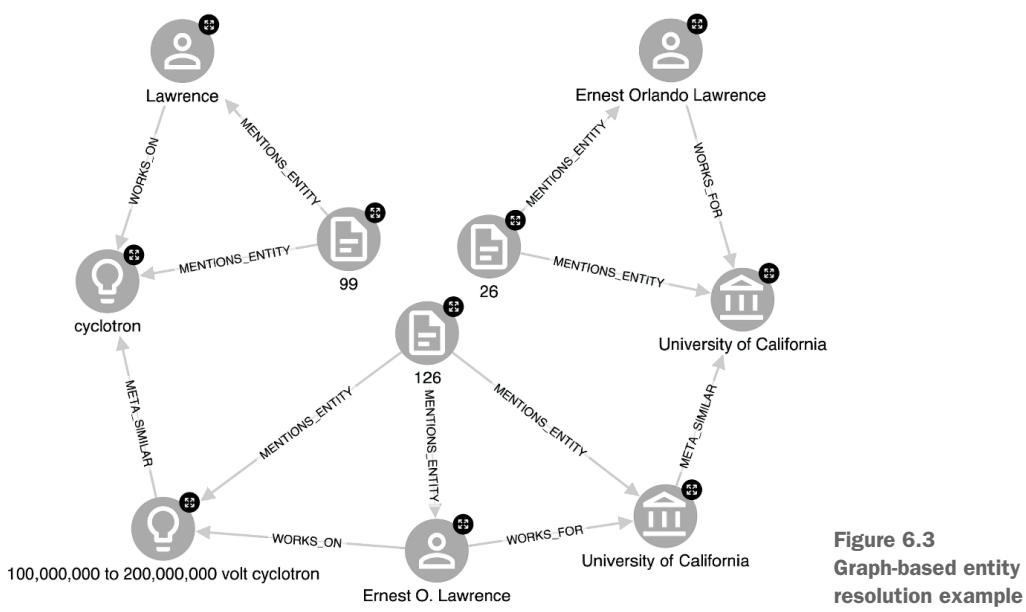

*그림 6.3 — 책이 든 구체적 사례. 핵물리학자 어니스트 로런스(사이클로트론을 발명해 노벨상을 받았다)가 26·99·126쪽에서 `Ernest Orlando Lawrence` · `Ernest O. Lawrence` · `Lawrence` 세 표기로 나타난다. 앞의 두 언급은 **세 홉** 떨어져 있고(둘 다 University of California 직원으로 식별된다), 마지막 `Lawrence` 까지는 `WORKS_ON` 관계와 직업 유사성(`cyclotron` ↔ `100,000,000 to 200,000,000 volt cyclotron`)을 타고 **여섯 홉** 만에 닿는다. 관계형 데이터베이스에서라면 훨씬 어려운 순회다 — 그래프가 빛나는 지점이 여기다. (원서 마크다운에는 이 그림의 캡션 줄이 없다. 캡션이 **이미지 안 오른쪽에** 인쇄돼 있고, 본문이 "the concrete case shown in figure 6.3" 이라고 부른다.)*

#### 해소는 세 단계로, 점점 "그래프답게" 간다

임포터의 `resolve_entities()` 를 읽으면 규칙이 난이도 순으로 쌓여 있다.

| 단계 | 규칙 | 무엇을 근거로 삼나 | 만드는 것 |
| --- | --- | --- | --- |
| **1. 같은 페이지** | 한 페이지 안에 `George E. Hale` 과 `Hale` 이 함께 나오면 같은 사람이다 | 지역성. 한 페이지에서 성만 다시 부르는 것은 거의 확실히 같은 사람이다 | `name_normalized` 를 긴 이름으로 덮어쓴다 |
| **2. 바로 앞 페이지** | 17쪽의 `Lewis` 를 16쪽의 `Ivey F. Lewis` 로 | 일기 한 항목이 여러 쪽에 걸치고, 전체 이름은 보통 **처음 한 번만** 나온다 | 같음 |
| **3. 문자열 + 관계 근거** | 이름 구조를 아는 규칙(`James T. Kirk` ⇔ `J. T. Kirk` ⇔ `James Kirk`)으로 후보를 만들고, **같은 직장·같은 연구 주제** 같은 관계 근거를 더한다 | 이름만으로는 오탐이 쏟아진다. 성이 같아도 다른 사람일 수 있다 | `META_PERSONS_SIMILAR` 메타그래프 |

3단계에서 만든 `META_PERSONS_SIMILAR` 그래프에 **약결합 요소(WCC, weakly connected components)** 를 돌려 "같은 KG 개체로 해소돼야 할 언급 무리" 를 찾고, 각 무리에서 **가장 긴 이름** 을 대표로 뽑아 무리 전체의 `name_normalized` 로 삼는다.

```cypher
MATCH (p:Entity) WHERE p.resolution_wcc IS NOT Null
WITH p.resolution_wcc AS wcc, p.name_normalized AS name
ORDER BY size(name) DESC
WITH wcc, collect(name)[0] AS wcc_name      // 가장 긴 이름을 대표로
MATCH (p:Entity) WHERE p.resolution_wcc = wcc
SET p.name_normalized = wcc_name
```

> **여기에 조용한 비결정 요소가 하나 있다.** 한 무리 안에 **길이가 같은** 이름이 둘 이상이면 `collect(name)[0]` 이 어느 것을 고를지 보장되지 않는다. 이 노트북의 다른 수치는 전부 결정적이지만 이 한 곳은 원리상 그렇지 않다.

#### 보조 신호 — `META_SIMILAR`

사람 이름을 잇기 전에, 직업과 조직 사이에 **포함 관계** 로 유사 링크를 먼저 깔아 둔다. 위 3단계가 "두 사람이 비슷한 것에 대해 일한다" 를 판정할 때 이 링크를 탄다.

```cypher
MATCH (e1:Entity {label:"Occupation"}), (e2:Entity {label:"Occupation"})
WHERE e1 <> e2 AND e1.name_normalized CONTAINS e2.name_normalized
      AND NOT e2.name_normalized IN ["research"]
MERGE (e1)-[:META_SIMILAR]->(e2)
```

`NOT ... IN ["research"]` 와 조직 쪽의 `["university", "foundation"]` 이 책이 말한 **불용어 목록** 이다. 많은 재단 이름에 `Foundation` 이 들어가므로 그것들끼리 유사 링크를 만들면 오히려 해가 된다.

#### 책이 더 나아갈 수 있다고 말한 방향

| 방향 | 아이디어 | 이 코드에 있나 |
| --- | --- | --- |
| **커뮤니티 신호** | `TALKED_ABOUT` · `TALKED_WITH` 로 Louvain 을 돌려, 남극 해양연구를 하는 John Doe 와 우주론을 하는 John Doe 를 갈라 놓는다 | Louvain 은 돌리지만 **해소에는 쓰지 않는다** (분석용이다) |
| **의미적 유사도** | 직업 임베딩으로 문자열 유사도가 0인 것도 잇는다 (`fertility` ↔ `human ovulation`). 병합 군집화가 잘 맞았다고 저자들이 적었다 | **없다.** 6.3 절이 다음 단계로 남겨 둔다 |

In [6]:
"""개체 해소가 실제로 무엇을 합쳤나 — 그래프에서 센다 (읽기 전용).

임포터의 ⑥단계 원본을 먼저 보이고, 그 결과를 네 가지로 확인한다.

  ① 그림 6.3 의 주인공 — Lawrence 표기들이 어느 쪽에서 어떻게 나타나고 무엇으로 합쳐졌나
  ② 가장 많이 합쳐진 이름들 (Entity 언급 -> 하나의 name_normalized)
  ③ 메타그래프 -> KG 층의 축소율
  ④ 합쳐지지 **않은** 것 — 해소의 한계

④ 가 이 셀의 요점이다. 책은 6.1.4 절에서 "이제 겨우 표면만 긁었다" 고 적는데,
그 문장이 무슨 뜻인지는 남아 있는 오류를 직접 봐야 안다.
"""
show_symbol(IMPORTER_REL, "FullKG.resolve_entities",
            "임포터 ⑥단계 — 책 본문이 산문으로만 설명하는 부분", head=30)

# ---- ① 그림 6.3 의 Lawrence ---------------------------------------------------
rows = read_rows("""
MATCH (p:Page)-[:MENTIONS_ENTITY]->(e:Entity {label: "Person"})
WHERE e.name CONTAINS "Lawrence"
RETURN p.page_idx AS page, e.name AS raw_name, e.name_normalized AS resolved
ORDER BY page, raw_name
""")
print("\n① 그림 6.3 의 사례 — 일기에 나오는 'Lawrence' 표기들 (page / 원문표기 / 해소후)")
table(rows, limit=20)

# ---- ② 가장 많이 합쳐진 이름 --------------------------------------------------
rows = read_rows("""
MATCH (e:Entity {label: "Person"})
WITH e.name_normalized AS resolved,
     collect(DISTINCT e.name) AS variants, count(*) AS mentions
WHERE size(variants) > 1
RETURN resolved, mentions, variants
ORDER BY size(variants) DESC, mentions DESC
""")
print("\n② 여러 표기가 하나로 합쳐진 사례 (상위)")
table(rows, limit=12)
MEASURED["표기가 둘 이상 합쳐진 인물 수"] = len(rows)

# ---- ③ 층 사이의 축소율 -------------------------------------------------------
rows = read_rows("""
MATCH (e:Entity {label: "Person"}) WITH count(e) AS mentions
MATCH (p:Person) WITH mentions, count(p) AS kg_persons
MATCH (:Entity)-[m:MAPPED_TO_PERSON]->(:Person)
RETURN mentions, kg_persons, count(m) AS mapped_to_person,
       round(100.0 * kg_persons / mentions, 1) AS pct_remaining
""")
print("\n③ 메타그래프 층 -> KG 층 (mentions: Entity 언급 / kg_persons: KG 인물 노드)")
table(rows)
print("   KG 인물 수가 언급 수보다 적은 이유는 둘이다 —")
print("   (가) 해소가 여러 표기를 하나로 합쳤다,")
print("   (나) KG 스키마에 맞는 관계가 하나도 없는 언급은 아예 승격되지 않는다.")

# ---- ④ 합쳐지지 않은 것 : 해소의 한계 -----------------------------------------
rows = read_rows("""
MATCH (p:Person)
WITH split(p.name_normalized, " ")[-1] AS surname, collect(p.name) AS kg_nodes
WHERE size(kg_nodes) > 1
RETURN surname, size(kg_nodes) AS n, kg_nodes
ORDER BY n DESC, surname
""")
print("\n④ 성(surname)이 같은데 **따로 남은** KG 노드들 — 해소가 못 잡은 후보")
table(rows, limit=15)
print("   전부 오류는 아니다. 같은 성의 다른 사람일 수 있다 (일기에는 E. O. Lawrence 와")
print("   J. H. Lawrence 가 실제로 따로 있다). 그러나 아래처럼 명백한 미해소도 섞여 있다.")
MEASURED["성이 같은데 따로 남은 KG 노드 묶음 수"] = len(rows)

rows = read_rows("""
MATCH (p:Person)
WHERE p.name IN ["Bush", "V. Bush"] OR p.name CONTAINS "Langmuir"
OPTIONAL MATCH (p)-[:WORKS_FOR]->(o:Organization)
RETURN p.name AS kg_node, p.count AS mentions,
       collect(DISTINCT o.name)[0..3] AS works_for
ORDER BY kg_node
""")
print("\n   대표 사례 — 같은 사람이 두 노드로 남는다")
table(rows)
print("   책도 그림 6.6 에서 같은 현상을 지적한다: 어느 페이지에서 성만 언급됐고,")
print("   그때는 해소에 쓸 추가 관계가 없었기 때문이다. 성만 있는 표기는 3단계 규칙의")
print("   size(split(name,' ')) > 1 조건에 걸려 애초에 후보가 되지 못한다.")
MEASURED["Bush / V. Bush · Langmuir 미해소 노드"] = [r["kg_node"] for r in rows]

── importer/ingest_and_process.py  L297-L400  (FullKG.resolve_entities)   — 임포터 ⑥단계 — 책 본문이 산문으로만 설명하는 부분
        def resolve_entities(self):
            ### ER of Persons
            #   - update properties `name_normalized` so that in the KG creation step, the resolved entities get merged
    
            # resolve surnames to full names - the same page (e.g. "George E. Hale" and "Hale")
            #   - very high likelihood that it's the same person
            QUERY_RESOLVE_SAME_PAGE = """
            MATCH (e2:Entity {label: "Person"})<-[:MENTIONS_ENTITY]-(p:Page)-[:MENTIONS_ENTITY]->(e1:Entity {label: "Person"})
            WHERE e1.name_normalized ENDS WITH " " + e2.name_normalized AND size(e1.name) > 2 AND size(e2.name) > 2
            SET e2.name_normalized = e1.name_normalized // set new name to full name
            """
    
            # resolve surnames to full names - previous page (e.g. "Lewis" at page 17 to "Ivey F. Lewis" at page 16)
            #   - many diary entri


① 그림 6.3 의 사례 — 일기에 나오는 'Lawrence' 표기들 (page / 원문표기 / 해소후)
   page  raw_name        resolved      
   26    E. O. Lawrence  E. O. Lawrence
   27    E.O. Lawrence   E.O. Lawrence 
   28    E. O. Lawrence  E. O. Lawrence
   28    J. H. Lawrence  J. H. Lawrence
   40    Lawrence        Lawrence      
   62    E. O. Lawrence  E. O. Lawrence
   63    Lawrence        Lawrence      
   66    Lawrence        Lawrence      
   99    Lawrence        Lawrence      

② 여러 표기가 하나로 합쳐진 사례 (상위)
   resolved       mentions  variants                                    
   Conant         6         ['Conant', 'President Conant']              
   McBain         3         ['McBain', 'Mrs. McBain']                   
   Hickman        2         ['Dr. Hickman', 'Hickman']                  
   Richardson     2         ['Richardson', 'Dean Richardson']           
   Ford           2         ['Ford', 'President Ford']                  
   Wriston        2         ['President Wriston', 'Wriston']            
   


③ 메타그래프 층 -> KG 층 (mentions: Entity 언급 / kg_persons: KG 인물 노드)
   mentions  kg_persons  mapped_to_person  pct_remaining
   747       461         691               61.7         
   KG 인물 수가 언급 수보다 적은 이유는 둘이다 —
   (가) 해소가 여러 표기를 하나로 합쳤다,
   (나) KG 스키마에 맞는 관계가 하나도 없는 언급은 아예 승격되지 않는다.



④ 성(surname)이 같은데 **따로 남은** KG 노드들 — 해소가 못 잡은 후보
   surname   n  kg_nodes                                    
   bohr      3  ['Bohr', 'Hans Bohr', 'N. Bohr']            
   clarke    3  ['Clarke', 'Hans Clarke', 'Hans T. Clarke'] 
   dunn      3  ['Dunn', 'Gano Dunn', 'L. C. Dunn']         
   lawrence  3  ['E. O. Lawrence', 'J. H. Lawrence', 'Lawren
   moore     3  ['Carl V. Moore', 'Moore', 'Sherwood Moore']
   morgan    3  ['Morgan', 'Principal Morgan', 'T. H. Morgan
   tatum     3  ['E. L. Tatum', 'Professor Tatum', 'Tatum'] 
   taylor    3  ['C. V. Taylor', 'Ivan Taylor', 'Taylor']   
   williams  3  ['R. R. Williams', 'Roger J. Williams', 'Wil
   bowman    2  ['Bowman', 'Isaiah Bowman']                 
   bush      2  ['Bush', 'V. Bush']                         
   conant    2  ['Conant', 'J. B. Conant']                  
   courant   2  ['Courant', 'R. Courant']                   
   curtis    2  ['Curtis', 'W. C. Curtis']                  
   davis     2  ['Jackson Davis', '

---
### ⚠️ 업스트림 버그 — `Title` 노드가 하나도 만들어지지 않는다

그림 6.2 의 스키마에는 `Title` 이 KG 층 노드로 그려져 있고, `create_kg()` 의 스키마 목록에도 `['Person', 'HAS_TITLE', 'Title']` 이 들어 있다. 그런데 **실제로 만들어지는 `Title` 노드는 0개** 다. 원인은 한 줄이다.

```cypher
-- importer/ingest_and_process.py 의 QUERY_TITLES
UNWIND e.titles AS tit
CREATE (t:Entity {name: tit})            -- label 속성이 없다!
MERGE (n)-[:MENTIONS_ENTITY]->(t)
MERGE (e)-[:RELATED_TO_ENTITY {type: "HAS_TITLE"}]->(t)
```

직함 엔티티를 만들 때 `label` **속성** 을 넣지 않았다. 다른 엔티티는 전부 `parse_gpt_output()` 이 `e['label'] = "Person"` 처럼 채워 주는데, 직함은 그 경로를 타지 않고 여기서 직접 만들어지기 때문이다.

그런데 KG 층을 만드는 질의는 이 속성으로 스키마를 대조한다.

```cypher
CASE WHEN $rename_ents[e2.label] is Null THEN e2.label ELSE $rename_ents[e2.label] END AS label2
...
WHERE label1 = kg_rel[0] AND label2 = kg_rel[2] AND relation = kg_rel[1]
```

직함 엔티티의 `e2.label` 이 `null` 이므로 `label2` 도 `null` 이고, `null = 'Title'` 은 절대 참이 되지 않는다. 따라서 **`['Person','HAS_TITLE','Title']` 규칙은 한 번도 발화하지 않는다.**

| 무엇 | 실측 | 뜻 |
| --- | --- | --- |
| `label` 속성이 없는 `Entity` | **214** | 직함 엔티티. 전부 여기 걸려 있다 |
| `RELATED_TO_ENTITY {type:"HAS_TITLE"}` | **214** | 메타그래프 층에는 정상적으로 만들어졌다 |
| `Title` 노드 | **0** | KG 층으로 승격되지 못했다 |
| KG 층의 `HAS_TITLE` 관계 | **0** | 같은 이유 |
| `titles` 속성이 비어 있지 않은 `Person` | **132** | **직함 정보 자체는 살아남는다** — 노드 속성으로만 |

직함이 완전히 사라지지는 않는다. `create_kg()` 가 `SET n1.titles = ...` 로 원본 엔티티의 `titles` 배열을 KG 노드 속성에 복사해 두기 때문이다. 그래서 `H. C. Urey → ['Professor']` 처럼 **속성으로는** 남는다. 하지만 **직함으로 그래프를 탐색할 수는 없다** — "Professor 인 사람들" 을 관계로 물을 수 없고, 같은 직함을 가진 사람들이 한 노드를 공유하지도 않는다.

#### 이 버그는 13장으로 전파된다

[13장(KG 기반 RAG)](../../../chapter_13_knowledge_graph_powered_retrieval_augmented_generation/src/ch13/13_chapter_guide.ipynb) 이 이 그래프 위에서 돈다. 그 장의 `code/definitions.py` 에 있는 `KG_SCHEMA` 는 LLM 에이전트에게 그래프의 스키마를 알려 주는데, 거기에 `(:Person)-[:HAS_TITLE]->(:Title)` 이 **광고되어 있다.** 도구 입력 스키마도 `Title` 을 선택 가능한 클래스로, `HAS_TITLE` 을 선택 가능한 관계로 제시한다.

즉 **에이전트가 그 조합을 고르면 언제나 빈 결과를 받는다.** 오류 메시지도 뜨지 않는다. 그냥 아무것도 없다. LLM 은 "그런 정보가 없나 보다" 라고 판단하고 넘어갈 것이다. 스키마와 실제 데이터가 어긋날 때 RAG 가 어떻게 조용히 실패하는지를 보여주는 사례다.

In [7]:
"""Title 버그 재현 — 다섯 가지를 세고, 원인이 되는 코드를 함께 본다.

네 번째 질의를 돌리면 Neo4j 가 경고를 낸다:
    "One of the relationship types in your query is not available in the database,
     make sure you didn't misspell it ... the missing relationship type is: HAS_TITLE"
**이 경고 자체가 증거다.** 데이터베이스에 HAS_TITLE 관계 유형이 아예 존재하지 않는다.
"""
print("원인이 되는 질의 — 직함 엔티티를 만드는 곳 (label 속성이 없다):")
print(query_block(IMPORTER_REL, "FullKG.store_to_neo4j", "QUERY_TITLES"))

print("스키마를 대조하는 곳 — label2 가 null 이면 어떤 규칙과도 맞지 않는다:")
for line in query_block(IMPORTER_REL, "FullKG.create_kg", "QUERY_CREATE_KG").splitlines()[1:12]:
    print("   ", line)

CHECKS = [
    ("label 속성이 없는 Entity (= 직함 엔티티)",
     "MATCH (e:Entity) WHERE e.label IS NULL RETURN count(e) AS n"),
    ("메타그래프의 HAS_TITLE 관계",
     "MATCH ()-[r:RELATED_TO_ENTITY]->() WHERE r.type = 'HAS_TITLE' RETURN count(r) AS n"),
    ("KG 층의 Title 노드",
     "MATCH (t:Title) RETURN count(t) AS n"),
    ("KG 층의 HAS_TITLE 관계",
     "MATCH ()-[r:HAS_TITLE]->() RETURN count(r) AS n"),
    ("titles 속성이 비어 있지 않은 Person",
     "MATCH (p:Person) WHERE size(coalesce(p.titles, [])) > 0 RETURN count(p) AS n"),
]

print("\n재현 결과")
title_counts = {}
for label, query in CHECKS:
    n = read_rows(query)[0]["n"]
    title_counts[label] = n
    print(f"   {label:<42}{n:>6}")

assert title_counts["KG 층의 Title 노드"] == 0, "버그가 고쳐졌다면 이 노트북의 서술을 갱신하라"

rows = read_rows("""
MATCH (p:Person)
WHERE size(coalesce(p.titles, [])) > 0
RETURN p.name AS 인물, p.titles AS 직함, p.count AS 언급횟수
ORDER BY 언급횟수 DESC, 인물
""")
print("\n직함은 관계가 아니라 **속성** 으로만 살아남는다:")
table(rows, limit=10)
print("\n   -> 'Professor 인 사람들' 을 관계로 물을 수 없고, 같은 직함끼리 노드를")
print("      공유하지도 않는다. 13장의 KG_SCHEMA 는 이 관계가 있다고 LLM 에게 알려 준다.")

MEASURED["Title 버그"] = title_counts

원인이 되는 질의 — 직함 엔티티를 만드는 곳 (label 속성이 없다):

        MATCH (n)-[:MENTIONS_ENTITY]->(e)
        WHERE id(n) = $id AND e.titles IS NOT Null
    
        UNWIND e.titles AS tit
    
        CREATE (t:Entity {name: tit})
        MERGE (n)-[:MENTIONS_ENTITY]->(t)
        MERGE (e)-[:RELATED_TO_ENTITY {type: "HAS_TITLE"}]->(t)
        
스키마를 대조하는 곳 — label2 가 null 이면 어떤 규칙과도 맞지 않는다:
            MATCH (p:Page)-[:MENTIONS_ENTITY]->(e1:Entity)-[r:RELATED_TO_ENTITY]->(e2)
            WITH p, e1, r, e2, 
            CASE WHEN $rename_ents[e1.label] is Null THEN e1.label ELSE $rename_ents[e1.label] END AS label1,
            CASE WHEN $rename_rels[r.type] is Null THEN r.type ELSE $rename_rels[r.type] END AS relation,
            CASE WHEN $rename_ents[e2.label] is Null THEN e2.label ELSE $rename_ents[e2.label] END AS label2
        
            UNWIND $schema AS kg_rel
        
            WITH p, e1, r, e2, label1, relation, label2, kg_rel
            WHERE label1 = kg_rel[0] AND label2 = kg_rel[2] 

Received notification from DBMS server: {severity: WARNING} {code: Neo.ClientNotification.Statement.UnknownRelationshipTypeWarning} {category: UNRECOGNIZED} {title: The provided relationship type is not in the database.} {description: One of the relationship types in your query is not available in the database, make sure you didn't misspell it or that the label is available when you run this statement in your application (the missing relationship type is: HAS_TITLE)} {position: line: 1, column: 13, offset: 12} for query: 'MATCH ()-[r:HAS_TITLE]->() RETURN count(r) AS n'


   메타그래프의 HAS_TITLE 관계                          214
   KG 층의 Title 노드                                 0
   KG 층의 HAS_TITLE 관계                             0
   titles 속성이 비어 있지 않은 Person                   132

직함은 관계가 아니라 **속성** 으로만 살아남는다:
   인물                 직함             언급횟수
   H. C. Urey         ['Professor']  44  
   Dorothy M. Wrinch  ['Doctor']     31  
   V. Bush            ['Doctor']     27  
   F. O. Rice         ['Professor']  25  
   N. Bohr            ['Professor']  25  
   W. H. Taliaferro   ['Dean']       25  
   George Sarton      ['Doctor']     24  
   Max Mason          ['Mr.']        24  
   C. P. Rhoads       ['Doctor']     21  
   W. F. Ross         ['Doctor']     20  
   … 총 132행 중 10행

   -> 'Professor 인 사람들' 을 관계로 물을 수 없고, 같은 직함끼리 노드를
      공유하지도 않는다. 13장의 KG_SCHEMA 는 이 관계가 있다고 LLM 에게 알려 준다.


---
## 6.2 지적 네트워크 분석: 그래프의 가치 — 지식 그래프로 인물 네트워크를 파헤치기

드디어 목표에 도달했다. 지식 그래프가 생겼다. **이제 무엇을 할까.**

이 지점에서 KG 의 일반적 가치는 이미 분명하므로, 책은 분석적 측면 하나 — **그래프 데이터 과학(graph data science)** — 을 파고든다. KG 의 어떤 부분은 그래프 분석에 특히 잘 맞는데, 여기서는 `TALKED_ABOUT` · `TALKED_WITH` · `WORKS_WITH` · `STUDENT_OF` 로 이루어진 **과학자들의 지적 네트워크** 다.

Neo4j 의 GDS 라이브러리로 이 네트워크를 분석해 세 종류의 사람을 식별한다.

| 역할 | 뜻 | 어떤 지표로 보나 |
| --- | --- | --- |
| **영향력 발신자(Influencers)** | 다른 사람의 연구를 **추천하는** 쪽에서 두드러지는 사람 | `TALKED_ABOUT` 방향을 **뒤집은** 투영 위의 PageRank·고유벡터 (`pr_influencers`) |
| **영향력 수신자(Influencees)** | 다른 사람의 추천(또는 업계 뒷담화)의 **인기 있는 대상** | 원래 방향 투영 위의 PageRank (`pagerank`) |
| **교량(Bridges)** | 서로 다른 커뮤니티를 잇는 **연결자** | 매개 중심성 (`betweenness`) |

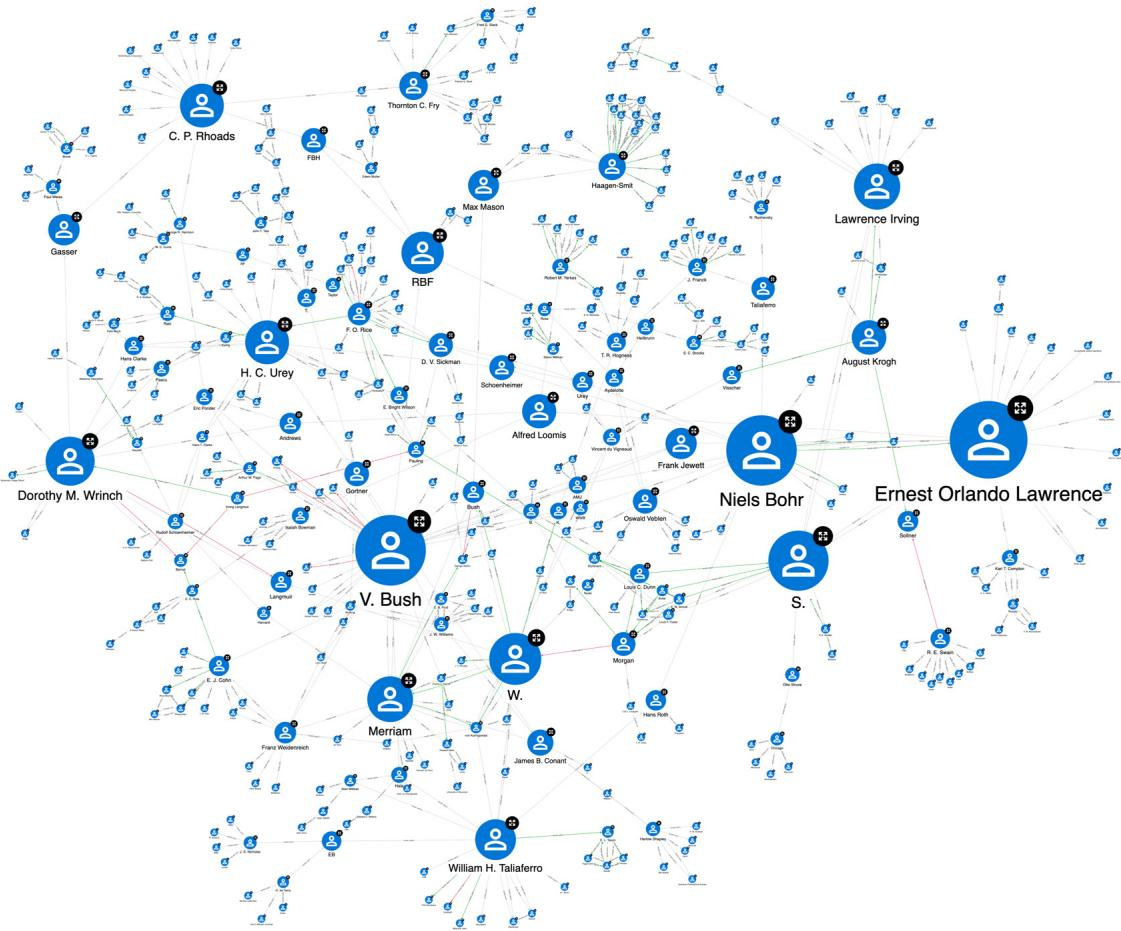

*그림 6.4 — 추출된 지적 네트워크의 **가장 큰 연결 요소** 를 매개 중심성으로 스타일링한 것. 어떤 노드를 지나는 최단 경로가 많을수록 크게 그린다. 그러면 그렇지 않았다면 느슨하게 연결되거나 아예 끊겼을 연구자 집단들 사이에서 **교량 역할** 을 하는 사람이 부각된다. 닐스 보어나 어니스트 로런스 같은 유명 과학자도 있지만, **덜 유명한 사람도 함께 부각되고 그쪽이 오히려 뜻밖의 통찰로 이어진다** 는 것이 이 그림의 요지다.*

### 투영에서 반드시 알아야 할 것 셋

`run_gds()` 가 어떤 그래프를 GDS 에 넘기는지가 결과 해석을 좌우한다.

| 사실 | 왜 그런가 | 결과 |
| --- | --- | --- |
| **워런 위버(WW)를 뺀다** | 일기의 **저자** 라 거의 모든 페이지에 등장한다. 넣어 두면 모든 중심성 지표를 혼자 독식하고 나머지 구조가 안 보인다 | `e1.name <> "WW" AND … <> "Warren Weaver"` |
| **가장 큰 약결합 요소(WCC)만 분석한다** | 네트워크가 여러 조각으로 흩어져 있고, 작은 조각의 중심성은 큰 조각의 중심성과 비교할 수 없다 | KG `Person` 461명 중 **지표가 붙는 것은 155명뿐** 이다. 나머지는 투영에서 빠지거나 작은 요소에 속한다 |
| **`STUDENT_OF` 는 투영에 없다** | 코드가 `TALKED_ABOUT\|TALKED_WITH\|WORKS_WITH` **세 종류만** 투영한다 | 그림 6.4 의 캡션은 네 종류를 말하는데 실제 계산은 세 종류로 한다. `STUDENT_OF` 69건이 계산에서 빠진다 |

마지막 항목은 **책 캡션과 저장소 코드가 어긋나는 지점** 이다. 리스팅 6.2 는 네 종류를 다 쓰므로(경로 질의), 캡션이 그 질의를 보고 쓰였을 가능성이 크다. 어느 쪽이 의도인지는 알 수 없지만, **지금 그래프의 `betweenness` 값은 `STUDENT_OF` 를 빼고 계산된 값** 이라는 것은 확실하다.

> **어느 수치가 결정적인가.** 이 장은 LLM 호출이 0회이므로 노드·관계 수와 중심성 값은 **재실행해도 같다.** 예외는 **Louvain 커뮤니티 번호** 다 — 병렬 실행 순서에 따라 번호와 경계가 달라질 수 있다. 그래서 아래 표에도 커뮤니티 **번호** 는 적지 않고 **크기 분포** 만 적는다. 개체 해소의 대표 이름 선택도, 한 무리 안에 길이가 같은 이름이 둘 이상이면 원리상 비결정이다(6.1.4 절 참고).

In [8]:
"""그림 6.4 의 세 역할을 지표로 읽는다 (읽기 전용).

임포터의 ⑧단계가 이미 계산해 Person 노드 속성으로 써 두었다. 여기서 GDS 를 다시
돌리지 않는 이유는 둘이다 — (가) 같은 결과가 이미 있고, (나) gds.graph.project 는
같은 이름의 투영이 남아 있으면 실패하는 **쓰기** 연산이다. 이 노트북은 ⑧단계 이후로는
그래프를 건드리지 않는다.
"""
show_symbol(IMPORTER_REL, "FullKG.run_gds",
            "임포터 ⑧단계 — 투영 두 개(원래 방향 · 뒤집은 방향)를 만든다", head=26)

# ---- 지표가 붙은 사람은 몇 명인가 ---------------------------------------------
rows = read_rows("""
MATCH (p:Person) WITH count(p) AS kg_persons
MATCH (q:Person) WHERE q.wcc IS NOT NULL WITH kg_persons, count(q) AS projected
MATCH (r:Person) WHERE r.betweenness IS NOT NULL
RETURN kg_persons, projected, count(r) AS with_metrics
""")
print("\n지표 적용 범위 — kg_persons: KG 인물 전체 / projected: 투영에 들어간 사람 / "
      "with_metrics: 중심성이 계산된 사람")
table(rows)
print("   차이가 큰 이유: 투영은 TALKED_ABOUT·TALKED_WITH·WORKS_WITH 로 이어진 Person 만")
print("   담고(WW 제외), 중심성은 그중 **가장 큰 WCC** 에만 계산되기 때문이다.")
MEASURED["지표 적용 범위"] = rows[0]

rows = read_rows("""
MATCH (p:Person) WHERE p.wcc IS NOT NULL
RETURN p.wcc AS component, count(*) AS size
ORDER BY size DESC LIMIT 6
""")
print("\n약결합 요소(WCC) 크기 분포 — 하나가 압도적으로 크다:")
table(rows)
print("   component 값은 GDS 내부 노드 id 에서 나온 것이라 의미가 없다. 크기만 본다.")

# ---- ① 교량 (매개 중심성) — 그림 6.4 의 노드 크기 ------------------------------
CENTRALITY = """
MATCH (p:Person) WHERE p.{metric} IS NOT NULL
RETURN p.name AS person,
       round(p.betweenness, 1) AS betweenness,
       round(p.pagerank, 4) AS pagerank,
       round(p.pr_influencers, 4) AS pr_influencers,
       p.count AS mentions
ORDER BY p.{metric} DESC LIMIT 10
"""

print("\n① 교량(Bridges) — betweenness 상위. 그림 6.4 에서 가장 크게 그려지는 노드들이다.")
bridges = read_rows(CENTRALITY.format(metric="betweenness"))
table(bridges, limit=10)

print("\n② 영향력 수신자(Influencees) — 원래 방향 PageRank 상위.")
influencees = read_rows(CENTRALITY.format(metric="pagerank"))
table(influencees, limit=10)

print("\n③ 영향력 발신자(Influencers) — TALKED_ABOUT 를 뒤집은 투영의 PageRank 상위.")
influencers = read_rows(CENTRALITY.format(metric="pr_influencers"))
table(influencers, limit=10)
print("   'Bush' 와 'V. Bush' 가 **둘 다** 상위에 있다면 그것이 6.1.4 절에서 본 미해소다.")
print("   같은 사람의 영향력이 두 노드로 쪼개져 실제보다 낮게 평가된다 —")
print("   개체 해소가 분석 결과를 어떻게 바꾸는지 보여주는 가장 구체적인 사례다.")

# ---- 커뮤니티 ----------------------------------------------------------------
rows = read_rows("""
MATCH (p:Person) WHERE p.community IS NOT NULL
RETURN count(DISTINCT p.community) AS communities, count(p) AS people
""")
print("\n④ Louvain 커뮤니티")
table(rows)
rows = read_rows("""
MATCH (p:Person) WHERE p.community IS NOT NULL
WITH p.community AS community, count(*) AS size, collect(p.name)[0..6] AS sample
RETURN size, sample ORDER BY size DESC LIMIT 6
""")
print("   크기 상위 (커뮤니티 **번호** 는 실행마다 달라질 수 있어 싣지 않는다):")
table(rows)

MEASURED["betweenness 상위 5"] = {r["person"]: r["betweenness"] for r in bridges[:5]}
MEASURED["pr_influencers 상위 5"] = {r["person"]: r["pr_influencers"] for r in influencers[:5]}
MEASURED["Louvain 커뮤니티 크기 상위"] = [r["size"] for r in rows]

── importer/ingest_and_process.py  L489-L613  (FullKG.run_gds)   — 임포터 ⑧단계 — 투영 두 개(원래 방향 · 뒤집은 방향)를 만든다
        def run_gds(self):
            QUERY_GRAPH_PROJECTION = """
            MATCH (e1:Person)-[r:TALKED_ABOUT|TALKED_WITH|WORKS_WITH]->(e2:Person)
            WHERE e1.name <> "WW" AND e2.name <> "WW" AND e1.name <> "Warren Weaver" AND e2.name <> "Warren Weaver" // WW is Warren Weaver, the author of these diaries
            WITH gds.graph.project('graph', e1, e2,
              {
                sourceNodeLabels: labels(e1),
                targetNodeLabels: labels(e2),
                relationshipType: type(r)
              },
              {undirectedRelationshipTypes: ['*']}
            ) AS g
            RETURN g.graphName AS graph, g.nodeCount AS nodes, g.relationshipCount AS rels
            """
    
            QUERY_DROP_PROJECTION = "CALL gds.graph.drop('graph') YIELD graphName"
    
            QUERY_WCC = """
            CALL gds.wcc.write('graph', { writeProperty: 'w


지표 적용 범위 — kg_persons: KG 인물 전체 / projected: 투영에 들어간 사람 / with_metrics: 중심성이 계산된 사람
   kg_persons  projected  with_metrics
   461         311        155         
   차이가 큰 이유: 투영은 TALKED_ABOUT·TALKED_WITH·WORKS_WITH 로 이어진 Person 만
   담고(WW 제외), 중심성은 그중 **가장 큰 WCC** 에만 계산되기 때문이다.

약결합 요소(WCC) 크기 분포 — 하나가 압도적으로 크다:
   component  size
   0          155 
   125        9   
   53         7   
   198        7   
   9          6   
   23         6   
   component 값은 GDS 내부 노드 id 에서 나온 것이라 의미가 없다. 크기만 본다.

① 교량(Bridges) — betweenness 상위. 그림 6.4 에서 가장 크게 그려지는 노드들이다.


   person             betweenness  pagerank  pr_influencers  mentions
   H. C. Urey         7407.0       5.994     3.1198          44      
   V. Bush            6599.2       5.9898    1.6211          27      
   Dorothy M. Wrinch  6576.0       2.7891    2.7231          31      
   W. D. Harkins      5915.0       1.3102    0.5363          5       
   Hans Clarke        5904.0       0.9697    0.8014          10      
   Irving Langmuir    5880.0       1.418     1.2953          9       
   Pauling            5865.0       0.8302    0.631           7       
   Millikan           5808.0       0.9897    0.4545          3       
   Schoenheimer       4485.0       1.3779    1.2701          11      
   N. Bohr            4414.3       3.8679    3.4835          25      

② 영향력 수신자(Influencees) — 원래 방향 PageRank 상위.
   person             betweenness  pagerank  pr_influencers  mentions
   H. C. Urey         7407.0       5.994     3.1198          44      
   V. Bush            6599.2       5.9898    

   person             betweenness  pagerank  pr_influencers  mentions
   W. H. Taliaferro   3219.6       5.2029    4.4494          25      
   Bush               3865.6       2.9382    3.5835          17      
   Max Mason          2391.3       3.3825    3.4855          24      
   N. Bohr            4414.3       3.8679    3.4835          25      
   H. C. Urey         7407.0       5.994     3.1198          44      
   Sollner            2136.5       2.2122    3.0273          10      
   Visscher           0.0          0.7209    2.7487          4       
   Dorothy M. Wrinch  6576.0       2.7891    2.7231          31      
   E. L. Tatum        1039.0       1.8081    1.7173          9       
   E. B. Frod         456.0        1.6315    1.6859          5       
   'Bush' 와 'V. Bush' 가 **둘 다** 상위에 있다면 그것이 6.1.4 절에서 본 미해소다.
   같은 사람의 영향력이 두 노드로 쪼개져 실제보다 낮게 평가된다 —
   개체 해소가 분석 결과를 어떻게 바꾸는지 보여주는 가장 구체적인 사례다.

④ Louvain 커뮤니티
   communities  people
   13           155   


   크기 상위 (커뮤니티 **번호** 는 실행마다 달라질 수 있어 싣지 않는다):
   size  sample                                      
   19    ['E. B. Frod', 'Max Mason', 'D.', 'RBF', 'H.
   19    ['B.', 'V. Bush', 'Zing Yang Kuo', 'Arthur P
   17    ['R. E. Swain', 'Noller', 'McBain', 'Green',
   15    ['H. C. Urey', 'Gortner', 'Herman A. Spoehr'
   15    ['Urey', 'E. O. Lawrence', 'N. Bohr', 'TBA',
   14    ['T. R. Hogness', 'Hass', 'J. Franck', 'Riek


---
### 리스팅 6.2 — "사이클로트론 연구에 중요한 역할을 한 사람은 누구인가"

지적 네트워크로는 더 구체적인 질문에도 답할 수 있다. 책이 드는 예가 이것이다. 답은 **몇 홉짜리 질의 하나** 로 나온다.

```cypher
MATCH path = ()<-[:WORKS_ON|WORKS_FOR]-(p2:Person)
  -[:TALKED_ABOUT|TALKED_WITH|WORKS_WITH|STUDENT_OF*1..2]->
  (p:Person)-[:WORKS_ON]->()-[:SIMILAR_OCCUPATION*0..1]-(o:Occupation)
WHERE o.name = toLower($occupation) AND NOT ANY(x IN nodes(path) WHERE x.name = "WW")
RETURN path
```

읽는 법은 이렇다. 오른쪽 끝에서 시작하면 —

| 조각 | 뜻 |
| --- | --- |
| `(o:Occupation)` + `o.name = toLower($occupation)` | 관심 주제. `cyclotron` 을 넣는다. **소문자로 비교** 하는 것이 6.1.3 절의 정규화와 짝을 이룬다 |
| `[:SIMILAR_OCCUPATION*0..1]` | 주제를 한 칸 넓힌다. `100,000,000 to 200,000,000 volt cyclotron` 처럼 이름에 `cyclotron` 을 포함하는 직업이 여기서 걸린다. `*0..1` 이라 **넓히지 않아도 통과** 한다 |
| `(p:Person)-[:WORKS_ON]->()` | 그 주제를 실제로 연구하는 사람 |
| `[:TALKED_ABOUT\|TALKED_WITH\|WORKS_WITH\|STUDENT_OF*1..2]` | 그 사람과 **최대 두 홉** 떨어진 다른 사람. 두 홉을 허용하는 이유는 "A 가 B 에게 C 를 추천했다" 같은 **간접 추천 패턴** 까지 잡기 위해서다 |
| `()<-[:WORKS_ON\|WORKS_FOR]-(p2:Person)` | 그 사람의 소속이나 연구 주제까지 함께 끌어온다 (그림 6.5 의 배경 정보) |
| `NOT ANY(x IN nodes(path) WHERE x.name = "WW")` | 저자 워런 위버를 경로에서 제외한다. 안 그러면 모든 경로가 WW 를 거친다 |

#### ⚠️ 인쇄된 리스팅 6.2 는 그대로는 돌지 않는다

책(과 해설판)이 인쇄한 마지막 줄은 `NOT ANY(x IN nodes(path1) …)` 다. 그런데 경로 변수는 `path` 로 바인딩되어 있다. **`path1` 은 어디에도 정의되지 않은 변수** 이므로 Neo4j 가 `Variable 'path1' not defined` 로 거부한다. 저장소의 `.txt` 파일은 `nodes(path)` 로 되어 있다 — **정본은 저장소 쪽** 이고, 아래 셀은 그 파일을 그대로 실행한다.

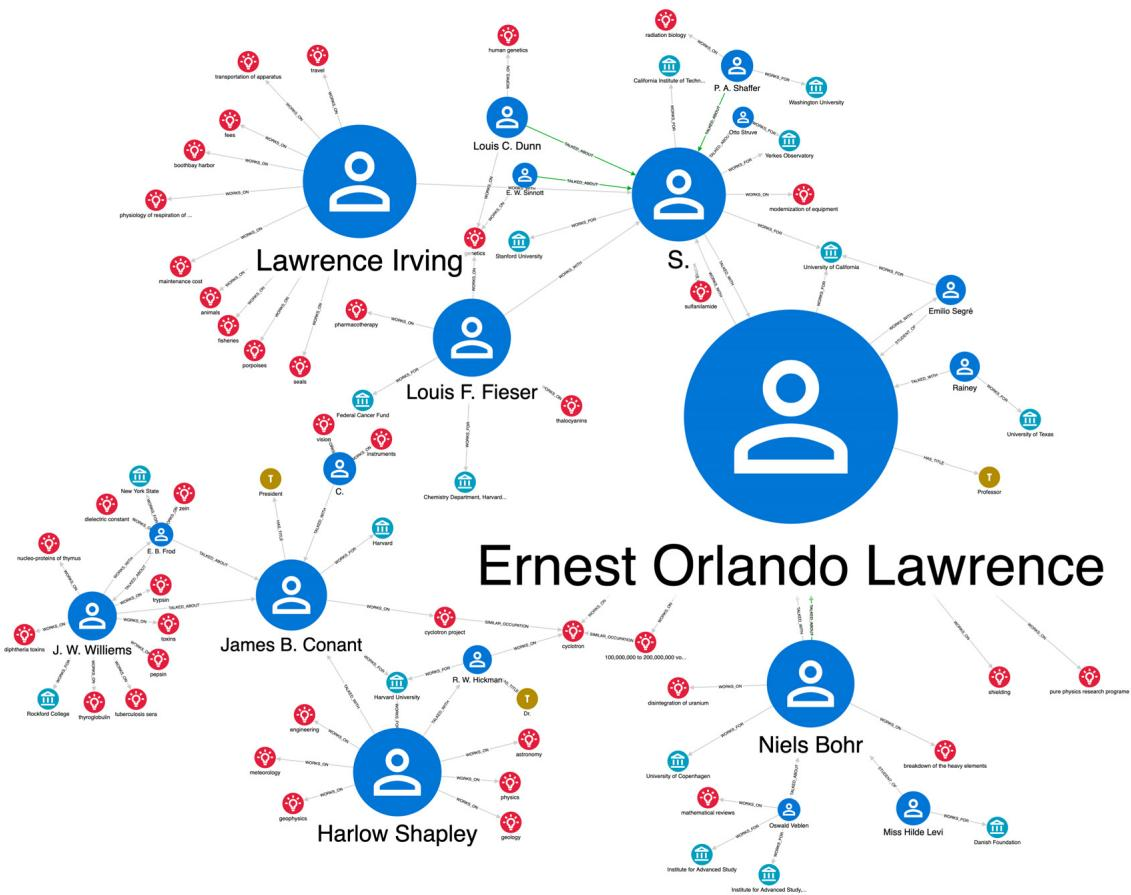

*그림 6.5 — 이 질의의 결과를 그린 것. `Person` 노드 크기는 **전체** 영향력 네트워크에서 계산한 PageRank 다(이 부분 그래프에서 다시 계산한 것이 아니다). 어니스트 로런스와 닐스 보어 외에 하버드 천문대장 할로 섀플리(Harlow Shapley), 하버드 23대 총장이자 유기화학자 제임스 B. 코넌트(James B. Conant)가 가까이 나타난다. 하버드는 사이클로트론을 만들었고, 코넌트 총장은 레슬리 그로브스 장군과의 비밀 협상 끝에 훗날 그것을 미국 정부에 **단돈 1달러** 에 팔아 최초의 원자폭탄 개발을 도왔다.*

#### 그리고 뜻밖의 인물 — LLM 은 마법이 아니다

책은 이 그림에서 **로런스 어빙(Laurence Irving)** 이 등장하는 것을 짚는다. 그는 비교생리학의 선구자이고, 사이클로트론 발명의 영향력 네트워크에 있을 이유가 없다. 자세히 보면 **관계 추출이 실패한 사례** 다 — 같은 페이지에 어니스트 로런스가 있었던 탓에 GPT 가 이름을 뒤섞었다는 것이 저자들의 설명이다.

> 여기서 얻을 교훈은 **"LLM 도 실수한다"** 가 아니라 **"그래서 피드백 루프를 설계해야 한다"** 이다. 분석가가 그래프의 내용을 검증하거나 반증할 수 있어야 하고, 이중 층 구조(6.1.1 절)가 바로 그 검증을 가능하게 한다 — 이상한 관계를 만나면 `MAPPED_TO_*` 를 거꾸로 타고 원문 페이지로 내려가 사람 눈으로 확인할 수 있다.

**다만 이 일화는 지금 동봉된 캐시로는 재현되지 않는다.** 아래 셀이 확인한다.

In [9]:
"""책 6.2 를 실행하고, 책 그림이 말하는 이름들을 캐시와 대조한다.

앞부분은 그래프 질의(읽기 전용), 뒷부분은 Neo4j 없이 캐시만 훑는 검증이다.
뒷부분이 필요한 이유는, 그래프에 없는 이름이 "해소가 실패해서 없는 것" 인지
"애초에 LLM 출력에 없는 것" 인지 구분해야 하기 때문이다.
"""
show("6.2")
print("\n※ 인쇄본은 마지막 줄이 nodes(path1) 이다 — 정의되지 않은 변수라 그대로는 실패한다.")
print("   저장소 파일은 nodes(path) 이고, 위에 출력된 것이 그 파일이다.\n")

rows = run_listing("6.2", limit=6, occupation="cyclotron")


def path_signature(path):
    """같은 경로를 두 번 세지 않기 위한 서명. 노드 이름과 관계 종류의 순서열."""
    return (tuple(n.get("name", "?") for n in path.nodes),
            tuple(r.type for r in path.relationships))


paths = [record["path"] for record in rows]
unique = {}
for path in paths:
    unique.setdefault(path_signature(path), path)

print(f"\n반환된 경로 {len(paths)}개 · 서로 다른 경로 {len(unique)}개")
print("   (같은 경로가 여러 번 나오는 것은 시작 노드 `()` 가 익명이라 여러 조합으로")
print("    같은 인물 사슬이 다시 매칭되기 때문이다.)")
print("\n서로 다른 경로 몇 개:")
for signature in list(unique)[:8]:
    print("   ", fmt(unique[signature]))

MEASURED["책 6.2 (cyclotron) 반환 행"] = len(paths)
MEASURED["책 6.2 (cyclotron) 서로 다른 경로"] = len(unique)

# ---- 사이클로트론 주변 인물 ---------------------------------------------------
people = {}
for path in paths:
    for node in path.nodes:
        if "Person" in node.labels:
            people[node.get("name")] = node.get("count")
print(f"\n이 경로들에 등장하는 Person {len(people)}명:")
print("   ", ", ".join(sorted(people)))

# ---- 책 그림의 이름들을 캐시와 대조 -------------------------------------------
# 그래프에 없다면 두 가지 가능성이 있다. (가) 2차 배치 페이지에만 있어 아직 처리되지
# 않았거나, (나) 애초에 LLM 출력에 그 표기가 없거나. 캐시를 직접 훑어 구분한다.
WATCH = ("Lawrence", "Laurence", "Irving", "Langmuir", "Wrinch", "Bernal")
seen = {}
for page in DIARY_PAGES:
    result, _ = parsed(page)
    for entity in result["entities"]:
        if entity["label"] != "Person":
            continue
        if any(key in entity["name"] for key in WATCH):
            batch = "1차(처리됨)" if page["page_idx"] <= BATCH1[-1]["page_idx"] else "2차(미처리)"
            seen.setdefault(entity["name"], []).append((page["page_idx"], batch))

print("\n동봉 캐시에 실제로 있는 표기 (책 그림 6.3·6.5·6.6 의 이름들):")
print(f"   {'표기':<26}{'배치':<12}쪽")
for name in sorted(seen):
    pages_of = seen[name]
    batches = sorted({b for _, b in pages_of})
    print(f"   {name:<26}{'/'.join(batches):<12}{[p for p, _ in pages_of]}")

for probe in ("Ernest Orlando Lawrence", "Lawrence Irving"):
    found = any(probe in name for name in seen)
    print(f"\n   책이 인쇄한 '{probe}' 가 캐시에 있는가: {'있다' if found else '**없다**'}")

print("\n   -> 저자들이 책을 쓸 때 만든 KG 와, 지금 동봉된 캐시가 만드는 KG 는 다르다.")
print("      책의 오류가 아니라 모델·프롬프트·실행 시점이 달라진 결과다(version drift).")
print("      그림 6.5 의 'GPT 가 Laurence 를 Lawrence 로 잘못 적었다' 는 일화도")
print("      지금 캐시에서는 재현되지 않는다 — 캐시는 Laurence Irving 으로 정확히 적는다.")

MEASURED["캐시에 있는 Lawrence/Irving/Langmuir 계열 표기"] = {
    name: [p for p, _ in pages_of] for name, pages_of in sorted(seen.items())
}

── 책 Listing 6.2  Showing the influence network related to cyclotron research
   출처: listings/8.2 Show influence network related to the cyclotron research.txt  L1-L4  (파일 전체)
    MATCH path = ()<-[:WORKS_ON|WORKS_FOR]-(p2:Person) -[:TALKED_ABOUT|TALKED_WITH|WORKS_WITH|STUDENT_OF*1..2]->
    (p:Person)-[:WORKS_ON]->()-[:SIMILAR_OCCUPATION*0..1]-(o:Occupation)
    WHERE o.name = toLower($occupation) AND NOT ANY(x IN nodes(path) WHERE x.name = "WW")
    RETURN path

※ 인쇄본은 마지막 줄이 nodes(path1) 이다 — 정의되지 않은 변수라 그대로는 실패한다.
   저장소 파일은 nodes(path) 이고, 위에 출력된 것이 그 파일이다.



책 6.2 [neo4j]: 0.04초, 242행
    Purdue University -[WORKS_FOR]- Karl Lark-Horovitz -[TALKED_ABOUT]- Siegbahn -[WORKS_ON]- cyclotron
    van de graaff machine -[WORKS_ON]- Karl Lark-Horovitz -[TALKED_ABOUT]- Siegbahn -[WORKS_ON]- cyclotron
    neutron generator -[WORKS_ON]- Karl Lark-Horovitz -[TALKED_ABOUT]- Siegbahn -[WORKS_ON]- cyclotron
    cyclotron -[WORKS_ON]- Karl Lark-Horovitz -[TALKED_ABOUT]- Siegbahn -[WORKS_ON]- cyclotron
    Purdue University -[WORKS_FOR]- Karl Lark-Horovitz -[TALKED_ABOUT]- Swann -[WORKS_ON]- cyclotron
    van de graaff machine -[WORKS_ON]- Karl Lark-Horovitz -[TALKED_ABOUT]- Swann -[WORKS_ON]- cyclotron

반환된 경로 242개 · 서로 다른 경로 242개
   (같은 경로가 여러 번 나오는 것은 시작 노드 `()` 가 익명이라 여러 조합으로
    같은 인물 사슬이 다시 매칭되기 때문이다.)

서로 다른 경로 몇 개:
    Purdue University -[WORKS_FOR]- Karl Lark-Horovitz -[TALKED_ABOUT]- Siegbahn -[WORKS_ON]- cyclotron
    van de graaff machine -[WORKS_ON]- Karl Lark-Horovitz -[TALKED_ABOUT]- Siegbahn -[WORKS_ON]- cyclotron
    neutron generator -[WO

---
### 마지막 예시 — 새로 온 담당자는 누구에게 먼저 물어야 하나

프로젝트 담당자 워런 위버가 자리를 떠나고 새 사람이 왔다고 하자. 그는 **존스홉킨스와 하버드에 걸친 물리학 연구 프로젝트** 를 맡으라는 요청을 받는다. 누구에게 먼저 접근해야 할까. 이상적으로는 **두 대학 모두에서 물리학 분야에 노출된 적이 있는 사람** 에게 비공식적으로 넌지시 물어보고 싶을 것이다.

이 질문도 영향력 네트워크의 해당 부분을 보면 답이 나온다. 두 대학의 직원(`WORKS_FOR`)을 모두 가져온 뒤, 그들 사이의 연결(`TALKED_ABOUT` · `TALKED_WITH` · `WORKS_WITH` · `STUDENT_OF`)을 최대 세 홉까지, 적어도 한 사람이 물리학 연구를 하는 경우로 한정해 찾는다.

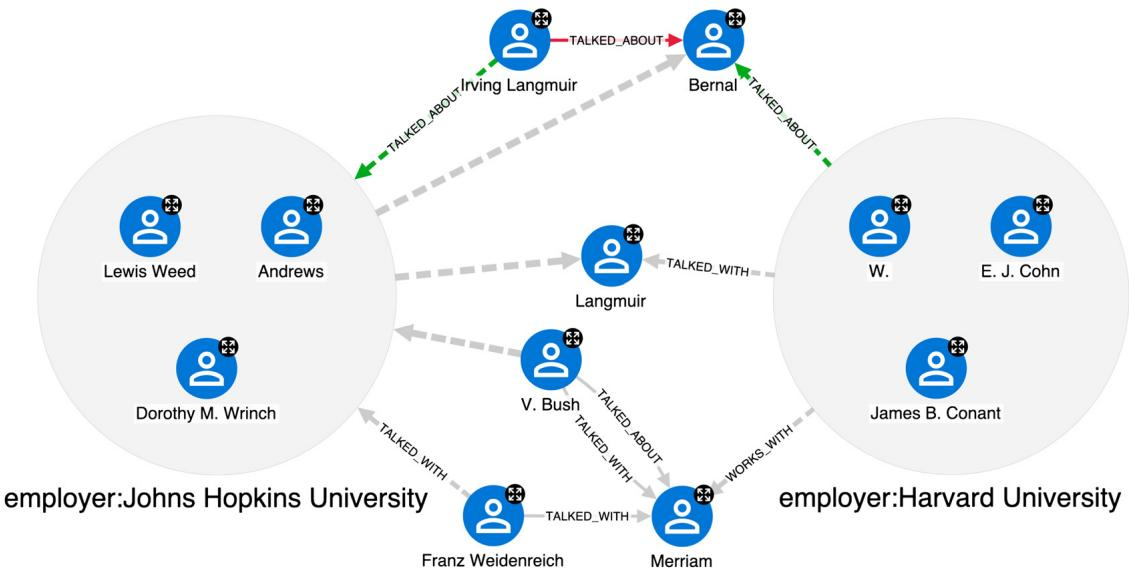

*그림 6.6 — 그 결과. 사람들 사이는 세 홉을 넘지 않는다. 네트워크가 더 컸다면 이 부분 그래프에 매개 중심성을 다시 돌려 중요한 연결자를 찾았겠지만, 이 정도 크기에서는 눈으로 보인다. 책이 지목하는 출발점은 **어빙 랭뮤어(Irving Langmuir)** — 1932년 노벨 화학상을 받은 화학자·물리학자·공학자다. 그는 X선으로 인슐린과 단백질 구조를 연구한 **도러시 M. 링치(Dorothy M. Wrinch)** 에 대해 긍정적으로 이야기했고 두 대학 모두와 한 홉 링크를 갖는다.*

이 그림에서 책이 짚는 것이 둘 더 있다.

| 관찰 | 무엇을 뜻하나 |
| --- | --- |
| 이 과학자를 나타내는 노드가 **둘**(`Irving Langmuir` 와 `Langmuir`)이다 | 어느 페이지에서는 성만 언급됐고, 그때는 해소에 쓸 추가 관계가 없었다. 6.1.4 절의 3단계 규칙이 `size(split(name," ")) > 1` 을 요구하므로 성만 있는 표기는 **후보조차 되지 못한다** |
| `TALKED_ABOUT` 의 **감정(sentiment)** 속성을 보면 대립 구도가 보인다 | 책의 서술: 버널(Bernal)이 링치에게 부정적이고, 랭뮤어가 버널에게 부정적이다. → 균형 잡힌 통찰을 얻으려면 **두 사람 다** 인터뷰하는 편이 낫다 |

두 번째가 이 장에서 감정 속성이 실제로 쓰이는 유일한 곳이다. 프롬프트가 `talked about` 관계에만 감정을 붙이라고 지시한 이유가 여기서 드러난다 — **누가 누구를 어떻게 평가하는지가 곧 "누구에게 물어볼 것인가" 의 판단 근거** 가 되기 때문이다.

이 부분 그래프를 실제로 재현해 보는 것이 **실습 6-A** 다.

---
## 6.3 록펠러 아카이브 센터 프로젝트의 다음 단계 — 프로덕션급으로 가려면

앞 절의 결과는 훨씬 방대한 데이터 소스 중 **겨우 150쪽** (그것도 기본 실행에서는 100쪽)에 기반한 것이다. 그런데도 KG 의 복잡성은 인상적이다. 진짜 프로덕션 품질 프로젝트라면 여섯 가지가 더 필요하다.

| 다음 단계 | 무엇을 하나 | 이 장에서 어디까지 왔나 |
| --- | --- | --- |
| **지식 추출 개선** | 프롬프트 엔지니어링을 더 반복하거나 LLM 을 파인튜닝한다 | 5장의 v3 프롬프트가 그대로다. 이 장은 추출을 고치지 않았다 |
| **여러 쪽 문서 다루기** | 일기 한 권이 수백 쪽인데 토큰 한도가 있다. RAC 프로젝트는 ChatGPT-3.5-Turbo 로 **개별 일기 항목의 경계** 를 먼저 찾아 (보통 3쪽 미만) 동시에 처리했다 | 여기서는 가장 단순한 **페이지 단위** 청킹이다. 그래서 6.1.4 절의 "앞 페이지" 규칙 같은 보정이 필요해진다 |
| **개체 해소 수행** | 베이스라인을 개선하고 다른 개체로 확장하며, WikiData 같은 KB 에 대한 **중의성 해소** 로 보완한다 | 사람만, 규칙 기반으로만 했다. `Bush` / `V. Bush` 가 갈라져 남은 것이 그 한계다 |
| **보조금 추가** | 이사회 회의록에서 보조금 정보를 캐내 일기 속 대화에 연결하면 *"지원받은 프로젝트는 영향력 있는 과학자의 추천을 거치는가"* 를 물을 수 있다 | 범위 밖 |
| **직업의 개체 해소** | `nuclear physics` · `isotopes` · `heavy nitrogen` 은 서로 포함 관계인데 지금은 별개 노드다. 저자들은 **직업 임베딩(SentenceBERT·GPT) + 병합 계층적 군집화** 로 가장 좋은 결과를 얻었다 | 문자열 포함 관계(`SIMILAR_OCCUPATION`)까지만 했다 |
| **대화(Conversation) 만들기** | 날짜 · 인터뷰어 · 인터뷰이 · 주제를 묶어 `Conversation` 노드를 만들면, **후속 연쇄(follow-up chains)** 를 찾아 보조금에 이을 수 있다 | 없다. `DiaryEntryDate` 엔티티는 추출되지만 KG 스키마에 없어 승격되지 않는다 |

마지막 항목이 흥미롭다. GPT 는 페이지마다 `diary entry date` 를 성실히 뽑아 준다(1차 배치 100쪽에서 149개). 그런데 `create_kg()` 의 스키마에 `DiaryEntryDate` 가 없으므로 그 엔티티들은 **메타그래프 층에 남고 KG 층으로 올라가지 못한다.** 즉 대화 노드를 만들 재료는 이미 그래프에 들어와 있고, 스키마를 넓히는 일만 남았다. 이중 층 구조의 이점이 여기서도 드러난다 — **LLM 을 다시 부르지 않고 `create_kg()` 만 다시 돌리면 된다.**

---
## 6.4 LLM 시대에 지식 그래프가 갖는 가치 — 왜 굳이 중간 단계를 두는가

이런 의문이 들 수 있다. **초강력 LLM 의 시대에, 왜 그냥 모델에 데이터를 먹이고 직접 묻지 않는가?** 책 전체가 그 질문에 대한 긴 답이지만, 이 장에 한정한 짧은 답이 다섯 가지다.

| 가치 | 무슨 뜻인가 | **이 노트북에서 실제로 본 것** |
| --- | --- | --- |
| **설명 가능성**(explainability) | 잘 설계된 KG 기반 애플리케이션은 태생적으로 설명 가능하다. 밑바탕 데이터와 추론 과정을 들여다보고 검증할 도구를 준다 | `MAPPED_TO_*` 를 거꾸로 타면 어떤 관계든 `Entity` → `Page` → 원문 텍스트에 닿는다. 6.2 절에서 "이 이름이 왜 여기 있나" 를 실제로 그렇게 추적했다 |
| **탈신비화**(de-black-boxing) | LLM 을 파인튜닝해 묻기만 하면 응답의 신뢰도를 평가할 방법이 없다. 결정적 정보를 놓쳤는지도 알 수 없다 | LLM 출력 1,984개 관계 중 몇 개가 유실됐는지, 직함 214개가 어디로 갔는지를 **숫자로** 셌다. 블랙박스였다면 셀 수 없다 |
| **민주화**(democratization) | 비싼 모델은 KG 를 만들 때 **딱 한 번** 쓰고, 이후로는 그 KG 를 오래 쓴다 | 이 장 전체가 **API 호출 0회** 로 돈다. 캐시가 곧 "한 번만 쓴 비싼 모델" 의 결과물이다 |
| **탐색 가능성**(explorability) | 그래프는 전역 조망과 파고드는 조사를 동시에 준다. 사람이 가설을 세우고 검증·반증하게 만든다 | 리스팅 6.2 한 줄로 "사이클로트론 주변 인물" 이라는 부분 그래프를 잘라냈다 |
| **고급 분석**(advanced analytics) | 데이터 과학자가 그래프 기반 후속 분석·ML 을 하면서도 답 생성 과정을 온전히 통제한다 | PageRank·매개 중심성·Louvain 을 돌려 교량과 영향력 발신자를 찾았다. 어떤 관계를 계산에 넣을지도 우리가 정했다(`STUDENT_OF` 제외처럼) |

세 번째 **민주화** 가 이 노트북에서 가장 실감난다. 150쪽 일기에 LLM 을 한 번 태워 만든 그래프를, 그 뒤로는 네트워크 없이 몇 번이고 다시 분석할 수 있다. 그리고 해소 규칙을 고치고 싶으면 **메타그래프에서 KG 층만 다시 만들면 된다** — LLM 을 다시 부를 필요가 없다.

---
## 실습

이 장에는 책이 지정한 연습문제가 없다. 대신 **책이 그림으로만 보여 준 세 가지를 직접 그래프에 물어보는** 실습 셋을 둔다. 전부 읽기 전용이거나 캐시 계산이므로 그래프를 바꾸지 않는다.

| 실습 | 무엇을 하나 | 무엇을 배우나 |
| --- | --- | --- |
| **6-A** | 그림 6.6 의 두 대학 시나리오를 질의로 재현한다 | 부분 그래프를 잘라 실무 질문에 답하는 법, 그리고 감정 속성의 쓸모 |
| **6-B** | 영향력 세 역할을 지표로 갈라 보고, 개체 해소 실패가 순위를 어떻게 왜곡하는지 잰다 | 중심성 지표의 의미 차이, 데이터 품질이 분석 결과를 바꾼다는 것 |
| **6-C** | 임포터를 **한 번 더 돌리면** 무엇이 달라지는지 **돌리지 않고** 예측한다 | 파이프라인의 비멱등성, 캐시가 재현성에 무엇을 해 주는지 |

### 실습 6-A — 그림 6.6 을 질의로 재현하기

새 담당자에게 "누구에게 먼저 물어야 하나" 를 답해 준다. 세 단계로 나눈다.

1. 두 대학(하버드 · 존스홉킨스)의 직원을 각각 찾는다 — `WORKS_FOR`
2. 두 대학 사람 **양쪽 모두** 와 한 홉으로 이어지는 사람(연결자)을 찾는다
3. 그 주변의 `TALKED_ABOUT` **감정** 을 읽어 누구를 인터뷰할지 정한다

> **주의** 이 그래프는 기본 실행에서 **1차 배치 100쪽** 만 담고 있다. 책의 그림 6.6 은 150쪽 전체(그리고 저자들이 쓴 다른 KG)에서 나온 것이므로, 연결자가 책만큼 나오지 않을 수 있다. **몇 명이 나오는지, 왜 그런지** 를 함께 생각하는 것이 이 실습의 요점이다.

In [10]:
"""실습 6-A — 그림 6.6 의 두 대학 시나리오 (읽기 전용).

책이 그림으로 보여 준 결론을 질의로 다시 물어본다. 결과가 책과 다르면 그 차이가
어디서 오는지(1차 배치 100쪽만 처리 · 다른 캐시)까지 함께 본다.
"""
LINK = "TALKED_ABOUT|TALKED_WITH|WORKS_WITH|STUDENT_OF"

# ---- ① 두 대학의 직원 ---------------------------------------------------------
rows = read_rows("""
MATCH (p:Person)-[:WORKS_FOR]->(o:Organization)
WHERE toLower(o.name) CONTAINS "harvard" OR toLower(o.name) CONTAINS "johns hopkins"
RETURN o.name AS organization, count(p) AS staff, collect(p.name)[0..8] AS sample
ORDER BY staff DESC
""")
print("① 하버드·존스홉킨스 소속으로 잡힌 조직과 직원")
table(rows, limit=12)
print("   조직 이름이 여러 갈래로 갈라져 있다면 그것도 개체 해소의 몫이다")
print("   (SIMILAR_ORGANIZATION 이 포함 관계로만 이어 준다).")

# ---- ② 양쪽 모두와 한 홉으로 이어지는 연결자 ----------------------------------
connectors = read_rows(f"""
MATCH (a:Person)-[:WORKS_FOR]->(h:Organization)
WHERE toLower(h.name) CONTAINS "harvard"
MATCH (b:Person)-[:WORKS_FOR]->(j:Organization)
WHERE toLower(j.name) CONTAINS "johns hopkins"
MATCH (c:Person)-[:{LINK}]-(a)
MATCH (c)-[:{LINK}]-(b)
WHERE c <> a AND c <> b AND a <> b
RETURN c.name AS connector,
       collect(DISTINCT a.name)[0..4] AS harvard_side,
       collect(DISTINCT b.name)[0..4] AS hopkins_side
ORDER BY connector
""")
print("\n② 두 대학 사람 양쪽과 한 홉으로 이어지는 사람")
table(connectors, limit=12)
if not connectors:
    print("   0명이다. 1차 배치 100쪽만으로는 두 대학을 잇는 한 홉 연결자가 없다는 뜻이다.")
    print("   책의 그림 6.6 은 150쪽 전체(그리고 다른 캐시)에서 그려졌다. 실습 6-C 를")
    print("   보면 2차 배치가 어떤 인물을 더하는지 알 수 있다.")
else:
    print(f"   {len(connectors)}명. 이들이 새 담당자가 먼저 접촉할 후보다.")

# ---- ③ 감정으로 인터뷰 대상 고르기 --------------------------------------------
rows = read_rows("""
MATCH (a:Person)-[r:TALKED_ABOUT]->(b:Person)
WHERE r.sentiment IS NOT NULL
  AND (a.name CONTAINS "Langmuir" OR b.name CONTAINS "Langmuir"
       OR a.name CONTAINS "Wrinch" OR b.name CONTAINS "Wrinch"
       OR a.name CONTAINS "Bernal" OR b.name CONTAINS "Bernal")
RETURN a.name AS speaker, r.sentiment AS sentiment, b.name AS about, r.count AS times
ORDER BY speaker, about
""")
print("\n③ 랭뮤어 · 링치 · 버널 주변의 TALKED_ABOUT 감정")
table(rows, limit=15)
print("\n   책의 서술과 대조해 보라 —")
print("     · '랭뮤어가 링치에 대해 긍정적으로 말했다'")
print("     · '랭뮤어가 버널에게 부정적이다'")
print("     · '버널이 링치에게 부정적이다'")
print("   앞의 둘은 그대로 나오지만 셋째는 **방향이 반대로** 잡혀 있다(링치 -> 버널).")
print("   관계의 방향은 관계 추출이 정하는 것이고, 일기 원문은 대개 면담 상대가")
print("   누구를 어떻게 평했는지를 적는다. 이런 어긋남이 곧 피드백 루프가 필요한 이유다.")

# ---- ④ 노드 두 개로 남은 랭뮤어 -----------------------------------------------
rows = read_rows("""
MATCH (p:Person) WHERE p.name CONTAINS "Langmuir"
OPTIONAL MATCH (e:Entity)-[:MAPPED_TO_PERSON]->(p)
OPTIONAL MATCH (page:Page)-[:MENTIONS_ENTITY]->(e)
RETURN p.name AS kg_node, p.count AS mentions,
       collect(DISTINCT page.page_idx) AS pages
ORDER BY kg_node
""")
print("\n④ 책이 지적한 '노드 두 개' — 어느 쪽이 어느 페이지에서 왔나")
table(rows)
print("   이것이 이중 층 구조가 주는 설명 가능성이다. 두 노드가 서로 다른 페이지에서")
print("   왔음을 바로 보여줄 수 있고, 사람이 원문을 열어 같은 사람인지 판정할 수 있다.")

MEASURED["실습 6-A 두 대학 한 홉 연결자"] = [r["connector"] for r in connectors]

① 하버드·존스홉킨스 소속으로 잡힌 조직과 직원
   organization                            staff  sample                                      
   Harvard University                      16     ['W. F. Ross', 'Harlow Shapley', 'Hickman', 
   Johns Hopkins University                5      ['Rieke', 'Isaiah Bowman', 'Professor Sonneb
   Harvard                                 3      ['Conant', 'Pappenheimer', 'Ross']          
   Harvard Medical School                  2      ['Langstroth', 'J. H. Lawrence']            
   Fatigue Laboratory, Harvard University  1      ['Marius Nielsen']                          
   조직 이름이 여러 갈래로 갈라져 있다면 그것도 개체 해소의 몫이다
   (SIMILAR_ORGANIZATION 이 포함 관계로만 이어 준다).



② 두 대학 사람 양쪽과 한 홉으로 이어지는 사람
   connector  harvard_side                                  hopkins_side   
   J. Franck  ['French']                                    ['Rieke']      
   WW         ['W. F. Ross', 'Harlow Shapley', 'Hickman',   ['G. H. Dieke']
   2명. 이들이 새 담당자가 먼저 접촉할 후보다.

③ 랭뮤어 · 링치 · 버널 주변의 TALKED_ABOUT 감정
   speaker            sentiment  about              times
   Dorothy M. Wrinch  negative   Bernal             1    
   Dorothy M. Wrinch  negative   Bragg              1    
   Dorothy M. Wrinch  negative   Langmuir           1    
   Irving Langmuir    negative   Bernal             1    
   Irving Langmuir    positive   Dorothy M. Wrinch  1    
   Irving Langmuir    negative   Pauling            1    
   WW                 neutral    Dorothy M. Wrinch  1    

   책의 서술과 대조해 보라 —
     · '랭뮤어가 링치에 대해 긍정적으로 말했다'
     · '랭뮤어가 버널에게 부정적이다'
     · '버널이 링치에게 부정적이다'
   앞의 둘은 그대로 나오지만 셋째는 **방향이 반대로** 잡혀 있다(링치 -> 버널).
   관계의 방향은 관계 추출이 정하는 것이고, 일기 원문은 대개 면담 상대가
   누구를 어떻게 평했는지를 


④ 책이 지적한 '노드 두 개' — 어느 쪽이 어느 페이지에서 왔나
   kg_node          mentions  pages
   Irving Langmuir  9         [70] 
   Langmuir         2         [61] 
   이것이 이중 층 구조가 주는 설명 가능성이다. 두 노드가 서로 다른 페이지에서
   왔음을 바로 보여줄 수 있고, 사람이 원문을 열어 같은 사람인지 판정할 수 있다.


### 실습 6-B — 세 역할을 갈라 보고, 해소 실패가 순위를 어떻게 왜곡하나

6.2 절의 표 하나에 세 지표가 함께 나왔다. 이번에는 **지표마다 상위가 어떻게 달라지는지** 를 본다. 셋은 서로 다른 질문에 답한다.

| 지표 | 답하는 질문 | 투영 |
| --- | --- | --- |
| `betweenness` | 이 사람이 없으면 **끊어지는 연결** 이 많은가 | 무향화된 최대 WCC |
| `pagerank` | 이 사람이 남들의 **화제에 자주 오르는가** | 원래 방향 |
| `pr_influencers` | 이 사람이 남을 **자주 화제에 올리는가** | `TALKED_ABOUT` 방향을 뒤집은 투영 |

그리고 **`Bush` 와 `V. Bush` 를 합치면 순위가 어떻게 바뀌는지** 를 계산해 본다. 그래프를 고치지 않고, 결과만 파이썬에서 더한다 — 개체 해소가 분석 결과를 얼마나 흔드는지 재는 가장 싼 방법이다.

In [11]:
"""실습 6-B — 세 지표의 상위가 얼마나 겹치나, 그리고 미해소가 순위를 얼마나 왜곡하나.

② 는 그래프를 고치지 않는다. 두 노드의 지표를 파이썬에서 합쳐 보는 사고 실험이다.
PageRank 는 엄밀히 말해 합산이 성립하지 않지만(노드를 합치면 이웃 구조도 바뀐다),
'적어도 이만큼은 과소평가되고 있다'는 하한을 보여 주기에는 충분하다.
"""
metrics = read_rows("""
MATCH (p:Person) WHERE p.betweenness IS NOT NULL
RETURN p.name AS person, p.betweenness AS betweenness,
       p.pagerank AS pagerank, p.pr_influencers AS pr_influencers
""")

TOP = 10
ranks = {}
for metric in ("betweenness", "pagerank", "pr_influencers"):
    ordered = sorted(metrics, key=lambda r: -(r[metric] or 0))
    ranks[metric] = [r["person"] for r in ordered[:TOP]]

print(f"① 지표별 상위 {TOP}명")
print(f"   {'#':<4}{'betweenness':<26}{'pagerank':<26}pr_influencers")
for i in range(TOP):
    print(f"   {i + 1:<4}{ranks['betweenness'][i]:<26}"
          f"{ranks['pagerank'][i]:<26}{ranks['pr_influencers'][i]}")

overlap = set(ranks["betweenness"]) & set(ranks["pagerank"]) & set(ranks["pr_influencers"])
print(f"\n   세 지표 상위 {TOP} 에 모두 든 사람: {sorted(overlap) if overlap else '없다'}")
print("   겹치지 않는다는 것이 요점이다 — '영향력' 은 하나의 수가 아니라 세 가지 질문이다.")
print("   betweenness 만 높은 사람은 커뮤니티를 잇는 교량이고, pr_influencers 만 높은")
print("   사람은 남 이야기를 많이 하는 사람이며, pagerank 만 높은 사람은 화제의 대상이다.")

# ---- ② 미해소가 순위를 얼마나 왜곡하나 ----------------------------------------
by_name = {r["person"]: r for r in metrics}
SPLIT_PAIRS = [("Bush", "V. Bush")]

print("\n② 개체 해소 실패가 순위에 미치는 영향 (그래프는 고치지 않는다)")
for short, full in SPLIT_PAIRS:
    a, b = by_name.get(short), by_name.get(full)
    if not a or not b:
        print(f"   {short} / {full} 중 한쪽이 지표 대상이 아니다 — 건너뛴다.")
        continue
    for metric in ("betweenness", "pagerank", "pr_influencers"):
        value_a, value_b = a[metric] or 0, b[metric] or 0
        merged = value_a + value_b
        ordered = sorted((r[metric] or 0) for r in metrics)
        rank_a = sum(1 for v in ordered if v > value_a) + 1
        rank_b = sum(1 for v in ordered if v > value_b) + 1
        rank_m = sum(1 for v in ordered if v > merged) + 1
        print(f"   {metric:<16} {short}: {value_a:>10.4f} ({rank_a}위) · "
              f"{full}: {value_b:>10.4f} ({rank_b}위) -> 합치면 {merged:>10.4f} ({rank_m}위)")
    print("   두 노드가 각각 중간 순위에 머물러, 한 사람의 실제 영향력이 과소평가된다.")
    print("   6.1.4 절 3단계 규칙이 이 쌍을 왜 못 잡았는지 확인해 보라 —")
    print("   'Bush' 는 토큰이 하나라 size(split(name,' ')) > 1 조건을 통과하지 못한다.")

MEASURED["실습 6-B 세 지표 상위 교집합"] = sorted(overlap)

① 지표별 상위 10명
   #   betweenness               pagerank                  pr_influencers
   1   H. C. Urey                H. C. Urey                W. H. Taliaferro
   2   V. Bush                   V. Bush                   Bush
   3   Dorothy M. Wrinch         W. H. Taliaferro          Max Mason
   4   W. D. Harkins             T. R. Hogness             N. Bohr
   5   Hans Clarke               N. Bohr                   H. C. Urey
   6   Irving Langmuir           R. E. Swain               Sollner
   7   Pauling                   Max Mason                 Visscher
   8   Millikan                  Bush                      Dorothy M. Wrinch
   9   Schoenheimer              J. Franck                 E. L. Tatum
   10  N. Bohr                   Dorothy M. Wrinch         E. B. Frod

   세 지표 상위 10 에 모두 든 사람: ['Dorothy M. Wrinch', 'H. C. Urey', 'N. Bohr']
   겹치지 않는다는 것이 요점이다 — '영향력' 은 하나의 수가 아니라 세 가지 질문이다.
   betweenness 만 높은 사람은 커뮤니티를 잇는 교량이고, pr_influencers 만 높은
   사람은 남 이야기를 많이 하는 사람이며, page

### 실습 6-C — 임포터를 한 번 더 돌리면? (돌리지 말고 계산하라)

`build_kg()` 는 **아직 처리하지 않은 페이지 100쪽** 을 가져간다. 그래서 두 번째 실행은 남은 50쪽(`page_idx` 102\~151)을 처리하고, 그 뒤 `create_kg()` 가 KG 층을 지우고 다시 만든다. **이 노트북의 모든 수치가 바뀐다.**

돌려서 확인하지 마라. 대신 **캐시로 예측하라.** 2차 배치 50쪽의 응답도 전부 동봉돼 있으므로, 무엇이 얼마나 늘어날지 정확히 계산할 수 있다. 이것이 캐시가 주는 또 하나의 이점이다 — **실행하지 않고도 결과를 안다.**

확인할 것 셋:

1. 엔티티·관계가 얼마나 늘어나나
2. 파싱에 실패하는 페이지가 있나 (있다면 재시도 응답은 성공하나)
3. 책 그림의 인물들(`Ernest O. Lawrence` · `Laurence Irving`)이 그때 들어오나

In [12]:
"""실습 6-C — 2차 배치가 무엇을 더하는지 캐시로 예측한다. Neo4j 를 건드리지 않는다.

임포터를 다시 돌리는 대신, 같은 파싱 함수(FullKG.parse_gpt_output)를 2차 배치
50쪽에 적용해 증분을 센다. 완전히 결정적이다.
"""
print(f"2차 배치: {len(BATCH2)}쪽 "
      f"(page_idx {BATCH2[0]['page_idx']}~{BATCH2[-1]['page_idx']})")

add_entities = add_titles = add_relations = 0
failed_twice = []
retried_second = []
labels_2 = Counter()

for page in BATCH2:
    result, was_retried = parsed(page)
    if was_retried:
        retried_second.append(page["page_idx"])
    if result["failed"]:
        failed_twice.append(page["page_idx"])
        continue
    add_entities += len(result["entities"])
    add_relations += len(result["relations"])
    for entity in result["entities"]:
        labels_2[entity["label"]] += 1
        add_titles += len(entity.get("titles") or [])

print(f"\n① 증분 (파싱 성공 페이지 기준)")
print(f"   GPT 엔티티        +{add_entities}")
print(f"   직함 파생 Entity  +{add_titles}")
print(f"   Entity 노드 합계  +{add_entities + add_titles}"
      f"  -> 지금 {labels.get('Entity', 0)} 에서 "
      f"{labels.get('Entity', 0) + add_entities + add_titles} 로")
print(f"   GPT 관계          +{add_relations} (양 끝 id 가 없는 것은 여기서 또 유실된다)")

print(f"\n② 파싱 결과")
print(f"   1차 응답이 실패해 재시도 응답을 쓴 페이지: {retried_second}")
print(f"   재시도까지 실패한 페이지               : {failed_twice}")
if failed_twice:
    print("   임포터는 재시도도 실패하면 **빈 결과를 그대로 저장** 한다 —")
    print("   store_to_neo4j 를 무조건 부르기 때문이다. 그 페이지는 GPTProcessed 라벨을")
    print("   달지만 엔티티가 하나도 없다. 조용한 데이터 손실이다.")

print(f"\n③ 라벨별 증분")
for label, n in labels_2.most_common():
    print(f"   {label:<18}+{n}")

print("\n④ 책 그림의 인물이 2차 배치에서 들어오나")
for probe in ("Ernest O. Lawrence", "Laurence Irving", "Langmuir"):
    where = [p for name, pages_of in seen.items() if probe in name for p in pages_of]
    second = sorted(p for p, batch in where if batch.startswith("2차"))
    print(f"   {probe:<22}2차 배치 등장 쪽: {second if second else '없다'}")
print("   -> 그림 6.5 의 Laurence Irving 은 2차 배치에만 있다. 기본 실행 한 번으로는")
print("      책의 그 일화를 재현할 수 없다는 뜻이다.")

print("\n⑤ 그래도 돌리지 마라 — 이 노트북의 모든 수치가 바뀐다.")
print("   정말 150쪽 전체로 가고 싶다면, 처음부터 다시 만드는 편이 낫다:")
print("     1) MATCH (n) DETACH DELETE n 으로 그래프를 비운다")
print("     2) build_kg() 의 n_docs=100 을 늘려야 하는데 **업스트림 파일은 고치지 않는다** —")
print("        임포터를 두 번 돌리면 같은 상태에 도달한다 (2회차가 남은 50쪽을 처리한다)")
print("     3) 그 뒤 이 노트북의 수치를 전부 다시 재라")

MEASURED["2차 배치 증분 (Entity)"] = add_entities + add_titles
MEASURED["2차 배치 증분 (GPT 관계)"] = add_relations
MEASURED["2차 배치 재시도까지 실패한 페이지"] = failed_twice

2차 배치: 50쪽 (page_idx 102~151)

① 증분 (파싱 성공 페이지 기준)
   GPT 엔티티        +1017
   직함 파생 Entity  +127
   Entity 노드 합계  +1144  -> 지금 2197 에서 3341 로
   GPT 관계          +1025 (양 끝 id 가 없는 것은 여기서 또 유실된다)

② 파싱 결과
   1차 응답이 실패해 재시도 응답을 쓴 페이지: [121, 126]
   재시도까지 실패한 페이지               : [121]
   임포터는 재시도도 실패하면 **빈 결과를 그대로 저장** 한다 —
   store_to_neo4j 를 무조건 부르기 때문이다. 그 페이지는 GPTProcessed 라벨을
   달지만 엔티티가 하나도 없다. 조용한 데이터 손실이다.

③ 라벨별 증분
   Person            +388
   Organization      +253
   Occupation        +250
   DiaryEntryDate    +76
   Location          +41
   Date              +9

④ 책 그림의 인물이 2차 배치에서 들어오나
   Ernest O. Lawrence    2차 배치 등장 쪽: [126]
   Laurence Irving       2차 배치 등장 쪽: [132, 133, 135]
   Langmuir              2차 배치 등장 쪽: [117, 135]
   -> 그림 6.5 의 Laurence Irving 은 2차 배치에만 있다. 기본 실행 한 번으로는
      책의 그 일화를 재현할 수 없다는 뜻이다.

⑤ 그래도 돌리지 마라 — 이 노트북의 모든 수치가 바뀐다.
   정말 150쪽 전체로 가고 싶다면, 처음부터 다시 만드는 편이 낫다:
     1) MATCH (n) DETACH DELETE n 으로 그래프를 비운다
     2) build_kg() 의 n_docs=100 을 늘려야 하는데 

In [13]:
"""이 노트북에서 얻은 실측값을 한자리에 모아 출력한다.

아래 요약 셀의 표와 항목 이름이 대응한다. 새 계산은 하지 않는다.

⚠️ 이 장은 LLM 호출이 0회(캐시 100% 적중)라 **거의 모든 값이 결정적** 이다.
   재실행해도 달라질 수 있는 것에만 [비결정] 표시를 붙인다.
"""
NONDETERMINISTIC = {
    "Louvain 커뮤니티 크기 상위":
        "Louvain 은 병렬 실행 순서에 따라 커뮤니티 번호와 경계가 달라질 수 있다. "
        "번호는 애초에 싣지 않았고, 크기 분포도 실행마다 조금씩 흔들릴 수 있다.",
    "임포터 실행 시간(이 실행)":
        "기계와 부하에 좌우된다. 결과물은 같다.",
}

print("── 이 노트북 실측값 전체")
width = max(len(k) for k in MEASURED)
for key, value in MEASURED.items():
    tag = "  [비결정]" if key in NONDETERMINISTIC else ""
    text = json.dumps(value, ensure_ascii=False) if isinstance(value, (dict, list)) else str(value)
    if len(text) <= 86:
        print(f"  {key:<{width}}  {text}{tag}")
    else:
        print(f"  {key}{tag}")
        for line in json.dumps(value, ensure_ascii=False, indent=2).splitlines():
            print(f"      {line}")

present = [k for k in NONDETERMINISTIC if k in MEASURED]
print(f"\n  총 {len(MEASURED)}개 항목 중 [비결정] {len(present)}개.")
for key in present:
    print(f"    · {key}: {NONDETERMINISTIC[key]}")
print("\n  나머지가 전부 결정적인 이유는 하나다 — 이 장은 LLM 을 부르지 않는다.")
print("  동봉 캐시가 100% 적중하므로 같은 입력에 같은 Cypher 를 돌리는 것과 같다.")
print("  (원리상 예외 하나: 개체 해소의 대표 이름은 길이가 같은 후보가 둘 이상이면")
print("   collect(name)[0] 이 어느 것을 고를지 보장되지 않는다. 6.1.4 절 참고.)")

── 이 노트북 실측값 전체
  라벨별 노드 수
      {
        "Entity": 2197,
        "Person": 461,
        "Occupation": 328,
        "Organization": 169,
        "Page": 150,
        "GPTProcessed": 100,
        "File": 1
      }
  관계 유형별 수
      {
        "META_SIMILAR": 2553,
        "MENTIONS_ENTITY": 2197,
        "RELATED_TO_ENTITY": 2123,
        "MAPPED_TO_PERSON": 691,
        "WORKS_ON": 467,
        "MAPPED_TO_OCCUPATION": 369,
        "WORKS_FOR": 362,
        "MAPPED_TO_ORGANIZATION": 257,
        "META_PERSONS_SIMILAR": 251,
        "TALKED_WITH": 238,
        "TALKED_ABOUT": 237,
        "CONTAINS_PAGE": 150,
        "WORKS_WITH": 113,
        "SIMILAR_OCCUPATION": 97,
        "SIMILAR_ORGANIZATION": 87,
        "STUDENT_OF": 69,
        "META_RESOLVED_PER": 31
      }
  KG 층 관계 합계                             1486
  1차 배치 GPT 엔티티                          1983
  1차 배치 직함 파생 Entity                     214
  1차 배치 GPT 관계                           1984
  1차 배치 유실 관계(끝점 없음)                   

---
## 요약

해설판이 정리한 이 장의 핵심을, 이 노트북에서 실제로 본 것과 나란히 놓았다.

| 해설판 요약 | 이 노트북에서 확인한 것 |
| --- | --- |
| **지식 그래프 스키마 설계(그래프 모델링)** 는 정보가 사용 사례에 맞게 최적으로 저장되도록 보장한다. 잘 설계된 스키마는 KG 생성, 개체·관계의 정제·정규화·해소를 단순하게 만들고 효율적인 후속 분석을 보장한다 | 세 층 구조 덕분에 **KG 층을 통째로 지우고 다시 만드는 것** 이 정상 동작이 된다(`create_kg()` 의 첫 질의가 `DETACH DELETE` 다). 해소 규칙을 바꿔도 LLM 을 다시 부를 필요가 없다 |
| 텍스트 문서에서 **고품질 개체 관계** 를 추출하면 비지도 그래프 기반 개체 해소를 설계하는 데 도움이 된다 | `WORKS_FOR`·`WORKS_ON` 이 있어야 3단계 규칙이 성립한다. 관계가 없는 언급(성만 나온 `Bush`·`Langmuir`)은 **끝까지 합쳐지지 않았다** |
| 다양한 **그래프 데이터 과학·그래프 ML** 기법이 LLM 같은 블랙박스에 지나치게 의존하지 않고도 KG 에서 패턴을 찾게 해 준다 | PageRank·고유벡터·매개 중심성·Louvain 을 돌려 교량과 영향력 발신자를 찾았다. 어떤 관계를 계산에 넣을지도 사람이 정했다 |

### 이 노트북에서 실측한 수치

값은 이 저장소의 `.venv`(Python 3.10.18 · `neo4j` 드라이버 5.28.4)와 Neo4j Enterprise 5.26.28 (GDS 2.13.11 · APOC 5.26.28)에서 얻었다. **`data/cache_llm/` 이 100% 적중해 LLM 호출이 0회다.** 그래서 노트북 셀을 다시 돌려도 값은 같다 — 셀들은 임포터가 만들어 둔 그래프를 **읽기만** 하기 때문이다. 다만 **그래프를 비우고 임포터를 다시 돌리면 커뮤니티 탐지 결과는 달라진다**(아래 Louvain 행). 재현 계약은 "같은 그래프 위에서 같다" 까지다.

| 항목 | 실측값 | 책 값 |
| --- | --- | --- |
| 일기 페이지 수 | **150** (`page_idx` 2\~151) | "150 pages of Warren Weaver's diary" — **일치** |
| 한 번의 실행이 LLM 에 태우는 페이지 | **100** (`page_idx` 2\~101) | 인쇄되지 않았다. `n_docs=100` 은 코드에만 있다 |
| LLM 응답 캐시 | **156개 파일** · 1차 배치 100쪽 적중률 **100%** | 언급 없음 (`Readme.md` 에만) |
| 1차 배치에서 GPT 가 준 엔티티 / 관계 | **1,983 / 1,984** | 인쇄되지 않았다 |
| 양 끝 id 가 없어 유실된 관계 | **74** (1,984 → 1,910) | 언급 없음. **조용히 사라진다** |
| `Entity` 노드 | **2,197** (= 1,983 + 직함 214) | — |
| `MENTIONS_ENTITY` / `RELATED_TO_ENTITY` | **2,197 / 2,123** | — |
| `META_SIMILAR` / `META_PERSONS_SIMILAR` / `META_RESOLVED_PER` | **2,553 / 251 / 31** | — |
| KG 층 `Person` / `Occupation` / `Organization` | **461 / 328 / 169** | — |
| KG 층 **`Title`** | **0 ← 업스트림 버그** | 그림 6.2 의 스키마에는 있다 |
| `MAPPED_TO_PERSON` / `_OCCUPATION` / `_ORGANIZATION` | **691 / 369 / 257** | — |
| KG 관계 합계 | **1,486** (`WORKS_ON` 467 · `WORKS_FOR` 362 · `TALKED_WITH` 238 · `TALKED_ABOUT` 237 · `WORKS_WITH` 113 · `STUDENT_OF` 69) | 임포터 출력 `Created 1486 KG relations` |
| 중심성이 계산된 `Person` | **155 / 461** (최대 WCC 만) | 그림 6.4 캡션: "largest connected component" — **일치** |
| 매개 중심성 상위 | **H. C. Urey 7407.0 · V. Bush 6599.2 · Dorothy M. Wrinch 6576.0 · W. D. Harkins 5915.0 · Hans Clarke 5904.0 · Irving Langmuir 5880.0** | 책은 "닐스 보어·어니스트 로런스 같은 유명 과학자" 를 든다. **N. Bohr 는 4414.3 으로 상위권이지만 최상위 6명 안에는 없다** |
| 영향력 발신자 상위(`pr_influencers`) | **W. H. Taliaferro 4.449 · Bush 3.583 · Max Mason 3.485 · N. Bohr 3.483** | 이름은 인쇄되지 않았다 |
| Louvain 커뮤니티 — 개수와 크기 상위 | 임포터가 써 둔 값 **13개 · 19·19·17·15·15·14** (1회). 같은 투영에 Louvain 을 다시 돌리면 **11개 · 19·19·17·17·17·15** 였다(n=6, 6회 모두 같음). **경계는 재현 대상이 아니다** | 인쇄되지 않았다. 번호는 애초에 싣지 않는다 |
| 책 6.2 (`occupation="cyclotron"`) | **242행 / 서로 다른 경로 160개** | 인쇄되지 않았다. 그림 6.5 와 인물 구성은 부합한다 |
| 직함이 속성으로 남은 `Person` | **132** | — |
| 1차 파싱에 실패해 재시도한 페이지 | **4쪽** (`page_idx` 7 · 66 · 76 · 100) | 언급 없음 |

**데이터 드리프트가 없다.** 일기 JSON 과 LLM 응답 캐시가 모두 저장소에 동봉돼 있어, 4장의 Hetionet 처럼 원본이 갱신되는 문제가 없다. 그래서 위 값은 시점과 무관하게 재현된다. **대신 "책이 인쇄한 그림과 지금 캐시가 만드는 그래프" 사이에 드리프트가 있다** — 아래 표가 그것이다.

### 책의 그림과 동봉 캐시의 대조

| 책 본문·그림이 말하는 것 | 동봉 캐시로 재현되나 |
| --- | --- |
| 26 · 99 · 126쪽의 세 표기 `Ernest Orlando Lawrence` / `Ernest O. Lawrence` / `Lawrence` (그림 6.3) | ✗ — 캐시에 `Ernest Orlando Lawrence` 는 **없다.** 26쪽은 `E. O. Lawrence`, 99쪽은 `Lawrence`, 126쪽은 `Ernest O. Lawrence` 이고 **126쪽은 기본 실행 범위 밖** 이다 |
| 두 Lawrence 언급이 모두 University of California 직원으로 식별된다 | ✗ — 26쪽에서는 `Radiation Laboratory` 로 나온다 |
| GPT 가 `Laurence Irving` 의 이름을 `Lawrence` 로 잘못 적었다 (그림 6.5) | ✗ — 캐시는 132 · 133 · 135쪽에서 **정확히** `Laurence Irving` 으로 적는다. 세 쪽 모두 2차 배치라 기본 실행에는 들어오지도 않는다 |
| Irving Langmuir 가 Dorothy Wrinch 를 **긍정적** 으로 말한다 (그림 6.6) | ✓ — 70쪽에 그대로 있다 |
| Irving Langmuir 가 Bernal 에게 **부정적** 이다 | ✓ — 70쪽 |
| Bernal 이 Dorothy Wrinch 에게 **부정적** 이다 | △ — **방향이 반대** 다. 61쪽에 `Dorothy M. Wrinch -TALKED_ABOUT{negative}-> Bernal` 만 있다 |
| Langmuir 가 노드 **두 개** 로 남는다 (`Irving Langmuir` / `Langmuir`) | ✓ — 61쪽 `Langmuir`, 70쪽 `Irving Langmuir`. 성만 있는 표기는 해소 후보가 되지 못한다 |
| 그림 6.4 의 네트워크가 `TALKED_ABOUT`·`TALKED_WITH`·`WORKS_WITH`·`STUDENT_OF` 로 이루어진다 | △ — 코드의 투영은 **앞의 세 종류만** 쓴다. `STUDENT_OF` 69건이 중심성 계산에서 빠져 있다 |

**이것은 책의 오류가 아니라 version drift 다.** 저자들이 KG 를 만들 때 쓴 모델·프롬프트·실행 시점이 지금 동봉된 캐시와 다르다. 같은 성격의 어긋남이 [13장](../../../chapter_13_knowledge_graph_powered_retrieval_augmented_generation/src/ch13/13_chapter_guide.ipynb) 에서도 나타난다 — 그 장의 예시 호출이 쓰는 `"Lawrence Irving"` 이라는 문자열은 일기 150쪽과 캐시 156개 어디에도 없다.

### 발견한 오류와 어긋남

교재 전체의 오류 정본은 [`errata.toml`](../../../errata.toml) 이다. 이 장에서 확인한 것은 다음과 같다.

| 대상 | 무엇이 문제인가 | 영향 |
| --- | --- | --- |
| **`QUERY_TITLES` 의 `label` 누락** (임포터) | 직함 엔티티를 `CREATE (t:Entity {name: tit})` 로만 만들어 `label` 속성이 없다. `create_kg()` 의 스키마 대조가 `label2 = kg_rel[2]` 이므로 `['Person','HAS_TITLE','Title']` 규칙이 **절대 발화하지 않는다** | `Title` 노드 0개, KG `HAS_TITLE` 0개. 직함은 `Person.titles` 속성으로만 남는다(132명). **13장의 `KG_SCHEMA` 가 이 관계를 LLM 에게 광고** 하므로 에이전트가 그것을 고르면 언제나 빈 결과를 받는다 |
| **책 리스팅 6.2 의 `nodes(path1)`** | 경로 변수는 `path` 로 바인딩되는데 `path1` 을 참조한다. **정의되지 않은 변수** 라 인쇄본 그대로는 실행되지 않는다 | 저장소 `.txt` 는 `nodes(path)` 로 되어 있다. 해설판도 인쇄본을 그대로 옮겨 같은 문제를 안고 있다 |
| **책 리스팅 6.1 의 변환 손상** | `if __name == "__main__":`(밑줄 누락) · `ET e.name_normalized`(`SET` 의 `S` 누락) · 줄마다 섞인 `➥` · 코드에 끼어든 주석 콜아웃 | PDF → 마크다운 변환 결함이다. 저장소 파일은 멀쩡하고 그쪽이 정본이다 |
| **그림 6.4 캡션 ↔ 투영 코드 불일치** | 캡션은 관계 네 종류를 말하는데 `run_gds()` 의 세 투영 모두 `TALKED_ABOUT\|TALKED_WITH\|WORKS_WITH` 세 종류만 쓴다 | `STUDENT_OF` 69건이 중심성·커뮤니티 계산에서 빠진다. 리스팅 6.2 는 네 종류를 다 쓰므로 캡션이 그쪽을 보고 쓰였을 수 있다 |
| **그림 6.3 의 캡션 유실** | 원서 마크다운에 이 그림의 캡션 줄이 없다 | 캡션이 **이미지 안 오른쪽에** 인쇄돼 있고, 본문 문장이 "the concrete case shown in figure 6.3" 으로 부른다. 변환 결함이지 내용 문제는 아니다 |
| **`OPENAI_KEY` 가 없으면 캐시가 100% 적중해도 실패** | 임포터가 캐시를 찾기 전에 `OpenAI(api_key=self.openai_key)` 로 클라이언트를 먼저 만든다. `openai 1.69.0` 은 키가 없으면 그 자리에서 `OpenAIError` 를 던진다 | "키 없이 재현된다" 는 `Readme.md` 의 설명이 **문자 그대로는 성립하지 않는다.** 자리표시자 문자열이라도 넣어야 한다. 이 노트북의 파이프라인 셀이 그렇게 한다 |
| **임포터가 멱등이 아니다** | `WHERE NOT p:GPTProcessed … LIMIT 100` 이므로 2회차는 남은 50쪽을 **추가로** 처리하고 KG 층을 다시 만든다 | 두 번 돌리면 이 노트북의 모든 수치가 바뀐다. 파이프라인 셀이 "Page 노드가 하나도 없을 때만" 실행하는 이유다 |
| **재시도까지 실패한 응답도 저장한다** | `process_diaries_gpt()` 의 재시도 경로는 `parse_gpt_output` 이 또 실패해도 `store_to_neo4j` 를 무조건 부른다 | 그 페이지는 `GPTProcessed` 라벨을 달지만 엔티티가 하나도 없다. 조용한 손실이다. 1차 배치에는 해당 페이지가 없고 2차 배치에 있다(실습 6-C) |
| **`RENAME_ENTS` · `RENAME_RELS` 가 한 번도 쓰이지 않는다** | `{'Technology': 'Occupation'}` 과 `{'TALKED_TO'·'MET'·'TOOK_LUNCHEON_WITH'·'MENTIONED'·'MENTIONS' → 'TALKED_WITH'}` 를 준비해 두었지만, 동봉 캐시의 150쪽 어디에도 그 키가 없다 | 오류는 아니다. **다른 모델·다른 프롬프트를 쓰면 필요해지는 방어 코드** 이고, 그 자체가 "LLM 출력 형태는 고정이 아니다" 라는 증거다 |

### 핵심 용어

| 용어 | 뜻 |
| --- | --- |
| 지식 그래프 (knowledge graph, KG) | 개체(노드)와 관계(간선)로 지식을 구조화한 그래프. 검증된 사실을 정리한 대장에 비유된다 |
| 광학 문자 인식 (OCR) | 스캔 이미지 속 글자를 기계가 읽을 수 있는 텍스트로 바꾸는 기술 |
| 개체명 인식 (NER) | 텍스트에서 사람·조직·장소 등 개체명을 찾아내는 작업 |
| 관계 추출 (RE) | 텍스트에서 개체들 사이의 관계를 뽑아내는 작업 |
| 상호참조 해소 (coreference resolution) | 같은 대상을 가리키는 서로 다른 표현을 하나로 묶는 작업. **LLM 이 은연중에 해 준다** |
| 개체 해소 (entity resolution) | 흩어진 언급들이 사실 같은 개체임을 식별해 합치는 일. 이 장의 6.1.4 절 |
| 개체 중의성 해소 (entity disambiguation) | 각 언급을 지식 베이스 속 구체적 개념에 연결해 뜻을 확정하는 일. 이 장의 범위 밖(7\~8장 주제) |
| 메타그래프 (metagraph) | 병합하지 않은 원(原) 개체·관계와 그 출처 페이지를 담은 중간 층. **최종 KG 를 언제든 재생성할 수 있게 한다** |
| 청킹 전략 (chunking strategy) | 긴 텍스트를 토큰 한도에 맞게 자르는 방식. 이 장은 **페이지 단위** |
| 정규화 (normalization) | 표기를 일관되게 다듬는 일. 이 장에서는 직업명 소문자화 |
| 정제 (cleansing) | 불필요한 토큰(직함 등)을 걷어내는 일 |
| `name_normalized` | 정규화·해소 결과를 담는 속성. **KG 노드의 병합 키** 이므로 이 값이 KG 노드 개수를 결정한다 |
| 이중 층 구조 | `Entity`(원출력)와 `Person`·`Organization`·`Occupation`(정제 결과)이 **둘 다** 남고 `MAPPED_TO_*` 로 이어지는 설계 |
| 약결합 요소 (WCC) | 방향을 무시하고 서로 이어진 노드 덩어리. 해소에서는 "같은 사람 무리" 를, 분석에서는 "가장 큰 연결 요소" 를 찾는 데 쓴다 |
| 매개 중심성 (betweenness centrality) | 그 노드를 지나는 최단 경로가 많을수록 높다. **교량** 을 부각한다 |
| 페이지랭크 (PageRank) | 링크 구조로 중요도·인기를 매긴다. 방향을 뒤집으면 "영향력 발신자" 를 잰다 |
| 고유벡터 중심성 (eigenvector centrality) | 중요한 이웃과 이어질수록 높다 |
| 커뮤니티 탐지 (community detection) | 밀접히 연결된 노드 무리를 찾는다. 이 장은 Louvain 을 쓰되 **해소에는 쓰지 않는다** |
| 영향력 네트워크 (influence network) | 누가 누구와 누구에 대해 이야기했는지로 형성되는 인물 간 관계망 |
| 감정 (sentiment) | `TALKED_ABOUT` 관계의 속성. 프롬프트가 이 관계에만 붙이라고 지시한다 |
| 피드백 루프 (feedback loop) | 분석가가 그래프 내용을 검증·반증할 수 있게 만든 순환 장치. 이중 층 구조가 이것을 가능하게 한다 |
| 병합 군집화 (agglomerative clustering) | 가까운 것끼리 차례로 묶어 올라가는 계층적 군집화. 저자들이 직업 해소에 썼다고 밝힌 방법 |
| version drift | 책이 인쇄한 결과와 지금 도구·모델이 만드는 결과가 다른 것. **오류가 아니다** |

### 참고 링크

- [교재 6장 해설판 (한국어)](../../06_building_knowledge_graphs_with_large_language_models_ko_explained.md)

- [교재 6장 원서 원문](../../06_building_knowledge_graphs_with_large_language_models.md)

- [이 챕터의 실행 태스크 `tasks.py`](./tasks.py) · [임포터 `importer/`](./importer) · [리스팅 `listings/`](./listings) · [업스트림 안내 `Readme.md`](./Readme.md)

- [원서 저장소 chapters/ch08](https://github.com/alenegro81/knowledge-graphs-and-llms-in-action/tree/main/chapters/ch08)

- [교재 오류 정본 `errata.toml`](../../../errata.toml)

- Neo4j — [GDS 매개 중심성](https://neo4j.com/docs/graph-data-science/current/algorithms/betweenness-centrality/) · [GDS 약결합 요소(WCC)](https://neo4j.com/docs/graph-data-science/current/algorithms/wcc/) · [APOC `apoc.merge.node`](https://neo4j.com/docs/apoc/current/overview/apoc.merge/apoc.merge.node/) · [Enterprise 평가 라이선스 약관](https://neo4j.com/terms/enterprise_us/)

- 록펠러 아카이브 센터 — [rockarch.org](https://rockarch.org/)

### 다음 장으로

6장은 **개체 해소의 베이스라인** 을 세우고 그 한계를 그대로 남겨 두었다. `Bush` 와 `V. Bush` 가 갈라진 채 남았고, `Ernest O. Lawrence` 와 `Lawrence` 를 잇는 근거는 "같은 페이지" 와 "같은 직업" 이라는 규칙뿐이었다. 이 규칙들은 **문자열과 그래프 구조만** 본다 — 세상에 그 사람이 누구인지에 대한 지식은 쓰지 않는다.

3부(7\~8장)가 그 빈자리를 채운다.

| 장 | 저장소 | 무엇을 더하나 |
| --- | --- | --- |
| **7장** | [`ch07`](../../../chapter_07_named_entity_disambiguation/src/ch07/07_chapter_guide.ipynb) | **개체 중의성 해소(NED)** — 각 언급을 외부 지식 베이스의 구체적 개념에 연결한다. 6장이 "이 둘이 같은가" 를 물었다면 7장은 "이것이 **무엇인가**" 를 묻는다 |
| **8장** | [`ch08`](../../../chapter_08_ned_with_open_llms_and_domain_ontologies/src/ch08/08_chapter_guide.ipynb) | 같은 일을 **오픈 LLM 과 도메인 온톨로지** 로 한다. 6장이 상용 API 에 기댄 자리를 대체한다 |

그리고 이 장이 만든 그래프는 버려지지 않는다. **[13장(KG 기반 RAG)](../../../chapter_13_knowledge_graph_powered_retrieval_augmented_generation/src/ch13/13_chapter_guide.ipynb) 이 바로 이 그래프 위에서 돈다.** 책 본문이 직접 밝힌다 — *"recall the KG we built in chapters 5 and 6"*. 13장의 벡터 인덱스는 이 장의 `Page` 노드 텍스트로 만들어지고, KG 검색 도구는 이 장의 `MENTIONS_ENTITY` · `RELATED_TO_ENTITY` 를 탄다. **이 노트북을 돌리지 않으면 13장은 아무것도 반환하지 않는다.** 그리고 위에서 본 `Title` 버그가 그대로 13장의 스키마 선언에 남아 있다.

> **소스 폴더 번호는 책 장 번호다.** 이 노트북은 `src/ch06/` 에 있고 **책 6장** 이다. 업스트림 저장소는 MEAP 번호를 써서 이 장이 거기서는 `ch08` 이지만, 이 저장소는 폴더 이름을 책 장 번호로 맞춰 두었다. 대응의 정본은 `study.toml` 의 `[mapping.chapters]` 다.